# Continued Process Verification (CPV) Analytics
## Synthetic Oral Solid Dosage Case Study

This notebook demonstrates a Python-based CPV workflow using synthetic manufacturing data. The analysis distinguishes specification compliance from statistical process behavior, identifies coordinated process signals, and prioritizes variables for investigation without claiming causality.


## 1. Data Import and Initial Inspection
Load the synthetic dataset and review its structure, summary statistics, reference-period split, and batch-level dissolution results.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("CPV_Synthetic_Source_Data.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (24, 13)


In [2]:
df.describe()

,API_PSD_D90_um,Compression_Force_kN,Tablet_Hardness_kp,Thickness_mm,Tablet_Weight_mg,Disintegration_min,Dissolution_30min_pct
count,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,79.166667,11.345833,7.500000,4.203750,500.458333,6.970833,91.916667
std,7.251187,0.991696,0.716271,0.010959,1.413573,0.876990,4.179834
min,71.000000,10.200000,6.700000,4.180000,498.000000,6.100000,82.000000
25%,74.750000,10.675000,7.000000,4.200000,499.750000,6.400000,91.500000
50%,76.000000,11.000000,7.250000,4.200000,500.000000,6.650000,93.500000
75%,81.750000,11.675000,7.625000,4.210000,501.250000,7.025000,95.000000
max,92.000000,13.300000,9.200000,4.220000,503.000000,9.200000,96.000000


In [3]:
df["Reference_Period"].value_counts()      

Reference_Period
Historical    18
Monitoring     6
Name: count, dtype: int64

In [4]:
df[["Batch_ID", "Dissolution_30min_pct"]]

,Batch_ID,Dissolution_30min_pct
0,B001,95
1,B002,94
2,B003,96
3,B004,93
4,B005,95
5,B006,94
6,B007,96
7,B008,95
8,B009,94
9,B010,93


## 2. Initial Dissolution Trend
Visualize batch-to-batch dissolution performance before applying historical-reference limits.


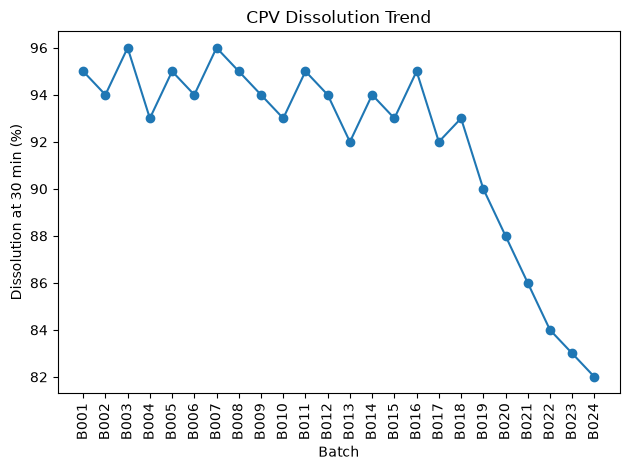

In [5]:

plt.plot(df["Batch_ID"], df["Dissolution_30min_pct"], marker="o")
plt.xticks(rotation=90)
plt.xlabel("Batch")
plt.ylabel("Dissolution at 30 min (%)")
plt.title("CPV Dissolution Trend")
plt.tight_layout()
plt.show()

## 3. Historical Reference and Provisional Control Limits
Use B001–B018 as the historical reference period, then calculate the historical mean, standard deviation, and provisional ±3 SD limits for dissolution.


In [6]:
historical = df[df["Reference_Period"] == "Historical"]
monitoring = df[df["Reference_Period"] == "Monitoring"]

In [7]:
historical_mean = historical["Dissolution_30min_pct"].mean()
monitoring_mean = monitoring["Dissolution_30min_pct"].mean()

historical_mean, monitoring_mean

(np.float64(94.05555555555556), np.float64(85.5))

In [8]:
historical_std = historical["Dissolution_30min_pct"].std()

historical_std

np.float64(1.2113299556429322)

In [9]:
ucl = historical_mean + 3 * historical_std
lcl = historical_mean - 3 * historical_std

ucl, lcl

(np.float64(97.68954542248436), np.float64(90.42156568862676))

In [10]:
df["Control_Status"] = df["Dissolution_30min_pct"].apply(
lambda x: "Below LCL" if x < lcl
else "Above UCL" if x > ucl
else "Within Limits"
)

df[["Batch_ID", "Dissolution_30min_pct", "Control_Status"]]

,Batch_ID,Dissolution_30min_pct,Control_Status
0,B001,95,Within Limits
1,B002,94,Within Limits
2,B003,96,Within Limits
3,B004,93,Within Limits
4,B005,95,Within Limits
5,B006,94,Within Limits
6,B007,96,Within Limits
7,B008,95,Within Limits
8,B009,94,Within Limits
9,B010,93,Within Limits


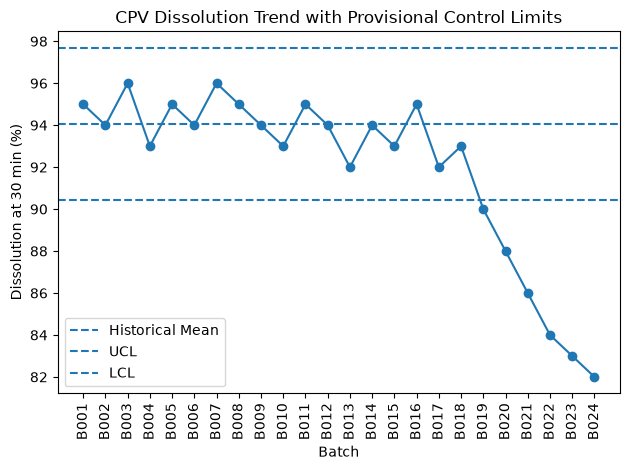

In [11]:

plt.plot(df["Batch_ID"], df["Dissolution_30min_pct"], marker="o")
plt.axhline(historical_mean, linestyle="--", label="Historical Mean")
plt.axhline(ucl, linestyle="--", label="UCL")
plt.axhline(lcl, linestyle="--", label="LCL")

plt.xticks(rotation=90)
plt.xlabel("Batch")
plt.ylabel("Dissolution at 30 min (%)")
plt.title("CPV Dissolution Trend with Provisional Control Limits")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Dissolution Signal Detection
Classify each batch relative to the historical dissolution limits and distinguish statistical process signals from specification status.


In [12]:
df["Dissolution_Signal"] = "Normal"

df.loc[df["Dissolution_30min_pct"] > ucl, "Dissolution_Signal"] = "Above UCL"
df.loc[df["Dissolution_30min_pct"] < lcl, "Dissolution_Signal"] = "Below LCL"

df[["Batch_ID", "Reference_Period", "Dissolution_30min_pct", "Dissolution_Signal"]]

,Batch_ID,Reference_Period,Dissolution_30min_pct,Dissolution_Signal
0,B001,Historical,95,Normal
1,B002,Historical,94,Normal
2,B003,Historical,96,Normal
3,B004,Historical,93,Normal
4,B005,Historical,95,Normal
5,B006,Historical,94,Normal
6,B007,Historical,96,Normal
7,B008,Historical,95,Normal
8,B009,Historical,94,Normal
9,B010,Historical,93,Normal


In [13]:
df.columns.tolist()

['Batch_ID',
 'Manufacture_Date',
 'Product',
 'Reference_Period',
 'API_Lot',
 'API_PSD_D90_um',
 'Compression_Force_kN',
 'Tablet_Hardness_kp',
 'Thickness_mm',
 'Tablet_Weight_mg',
 'Disintegration_min',
 'Dissolution_30min_pct',
 'Spec_Status',
 'Control_Status',
 'Dissolution_Signal']

In [14]:
df.loc[
    df["Reference_Period"] == "Monitoring",
    ["Batch_ID", "Dissolution_30min_pct", "Spec_Status", "Dissolution_Signal"]
]

,Batch_ID,Dissolution_30min_pct,Spec_Status,Dissolution_Signal
18,B019,90,Pass,Below LCL
19,B020,88,Pass,Below LCL
20,B021,86,Pass,Below LCL
21,B022,84,Pass,Below LCL
22,B023,83,Pass,Below LCL
23,B024,82,Pass,Below LCL


## 5. Monitoring-Period Process Relationships
Review monitoring-batch material and process parameters, quantify correlations with dissolution, and visualize the compression-force relationship. Correlation is used for investigation prioritization only and does not establish causality.


In [15]:
df.loc[
    df["Reference_Period"] == "Monitoring",
    [
        "Batch_ID",
        "API_PSD_D90_um",
        "Compression_Force_kN",
        "Tablet_Hardness_kp",
        "Disintegration_min",
        "Dissolution_30min_pct"
    ]
]

,Batch_ID,API_PSD_D90_um,Compression_Force_kN,Tablet_Hardness_kp,Disintegration_min,Dissolution_30min_pct
18,B019,90,12.5,8.0,7.4,90
19,B020,91,12.7,8.3,7.8,88
20,B021,90,12.9,8.5,8.1,86
21,B022,92,13.0,8.7,8.5,84
22,B023,91,13.2,9.0,8.9,83
23,B024,92,13.3,9.2,9.2,82


In [16]:
monitoring_cols = [
    "API_PSD_D90_um",
    "Compression_Force_kN",
    "Tablet_Hardness_kp",
    "Disintegration_min",
    "Dissolution_30min_pct"
]

df.loc[
    df["Reference_Period"] == "Monitoring",
    monitoring_cols
].corr()["Dissolution_30min_pct"].sort_values()

Compression_Force_kN    -0.991293
Disintegration_min      -0.988426
Tablet_Hardness_kp      -0.985157
API_PSD_D90_um          -0.725476
Dissolution_30min_pct    1.000000
Name: Dissolution_30min_pct, dtype: float64

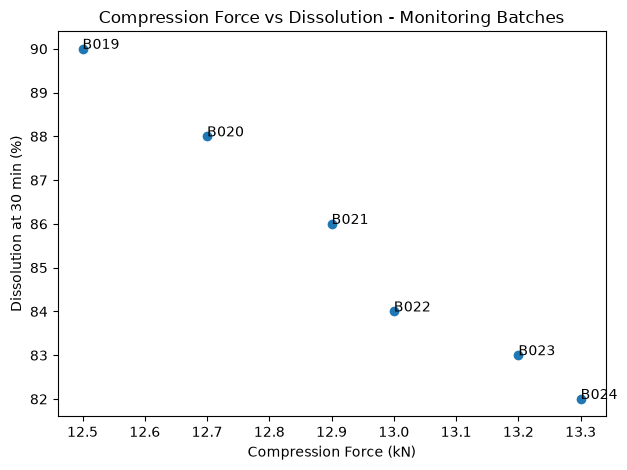

In [17]:
monitoring_df = df[df["Reference_Period"] == "Monitoring"]

plt.scatter(
    monitoring_df["Compression_Force_kN"],
    monitoring_df["Dissolution_30min_pct"]
)

for _, row in monitoring_df.iterrows():
    plt.annotate(
        row["Batch_ID"],
        (row["Compression_Force_kN"], row["Dissolution_30min_pct"])
    )

plt.xlabel("Compression Force (kN)")
plt.ylabel("Dissolution at 30 min (%)")
plt.title("Compression Force vs Dissolution - Monitoring Batches")
plt.tight_layout()
plt.show()

## 6. Process-Parameter and Intermediate-Response Signals
Compare compression force, tablet hardness, and disintegration against historical behavior and create statistical signal flags.


In [18]:
cf_hist = df.loc[
    df["Reference_Period"] == "Historical",
    "Compression_Force_kN"
]

cf_mean = cf_hist.mean()
cf_std = cf_hist.std()

cf_ucl = cf_mean + 3 * cf_std
cf_lcl = cf_mean - 3 * cf_std

print("Historical Compression Force Mean:", round(cf_mean, 2))
print("Compression Force UCL:", round(cf_ucl, 2))
print("Compression Force LCL:", round(cf_lcl, 2))

df.loc[
    df["Reference_Period"] == "Monitoring",
    ["Batch_ID", "Compression_Force_kN"]
]

Historical Compression Force Mean: 10.82
Compression Force UCL: 11.85
Compression Force LCL: 9.79


,Batch_ID,Compression_Force_kN
18,B019,12.5
19,B020,12.7
20,B021,12.9
21,B022,13.0
22,B023,13.2
23,B024,13.3


In [19]:
df["Compression_Signal"] = "Normal"

df.loc[
    df["Compression_Force_kN"] > cf_ucl,
    "Compression_Signal"
] = "Above UCL"

df.loc[
    df["Compression_Force_kN"] < cf_lcl,
    "Compression_Signal"
] = "Below LCL"

df.loc[
    df["Reference_Period"] == "Monitoring",
    ["Batch_ID", "Compression_Force_kN", "Compression_Signal"]
]

,Batch_ID,Compression_Force_kN,Compression_Signal
18,B019,12.5,Above UCL
19,B020,12.7,Above UCL
20,B021,12.9,Above UCL
21,B022,13.0,Above UCL
22,B023,13.2,Above UCL
23,B024,13.3,Above UCL


In [20]:
hardness_hist = df.loc[
    df["Reference_Period"] == "Historical",
    "Tablet_Hardness_kp"
]

disint_hist = df.loc[
    df["Reference_Period"] == "Historical",
    "Disintegration_min"
]

hardness_ucl = hardness_hist.mean() + 3 * hardness_hist.std()
hardness_lcl = hardness_hist.mean() - 3 * hardness_hist.std()

disint_ucl = disint_hist.mean() + 3 * disint_hist.std()
disint_lcl = disint_hist.mean() - 3 * disint_hist.std()

print("Hardness Mean:", round(hardness_hist.mean(), 2))
print("Hardness UCL:", round(hardness_ucl, 2))
print("Hardness LCL:", round(hardness_lcl, 2))

print()

print("Disintegration Mean:", round(disint_hist.mean(), 2))
print("Disintegration UCL:", round(disint_ucl, 2))
print("Disintegration LCL:", round(disint_lcl, 2))

Hardness Mean: 7.13
Hardness UCL: 7.79
Hardness LCL: 6.46

Disintegration Mean: 6.52
Disintegration UCL: 7.21
Disintegration LCL: 5.84


In [21]:
df["Hardness_Signal"] = "Normal"
df["Disintegration_Signal"] = "Normal"

df.loc[
    df["Tablet_Hardness_kp"] > hardness_ucl,
    "Hardness_Signal"
] = "Above UCL"

df.loc[
    df["Disintegration_min"] > disint_ucl,
    "Disintegration_Signal"
] = "Above UCL"

df.loc[
    df["Reference_Period"] == "Monitoring",
    [
        "Batch_ID",
        "Compression_Signal",
        "Hardness_Signal",
        "Disintegration_Signal",
        "Dissolution_Signal"
    ]
]

,Batch_ID,Compression_Signal,Hardness_Signal,Disintegration_Signal,Dissolution_Signal
18,B019,Above UCL,Above UCL,Above UCL,Below LCL
19,B020,Above UCL,Above UCL,Above UCL,Below LCL
20,B021,Above UCL,Above UCL,Above UCL,Below LCL
21,B022,Above UCL,Above UCL,Above UCL,Below LCL
22,B023,Above UCL,Above UCL,Above UCL,Below LCL
23,B024,Above UCL,Above UCL,Above UCL,Below LCL


## 7. Multivariate Signal Summary and KPI Layer
Combine individual statistical flags into a batch-level signal count, CPV status, signal matrix, and monitoring KPIs.


In [22]:
signal_cols = [
    "Compression_Signal",
    "Hardness_Signal",
    "Disintegration_Signal",
    "Dissolution_Signal"
]

df["Signal_Count"] = df[signal_cols].ne("Normal").sum(axis=1)

df["CPV_Status"] = "Stable"

df.loc[
    (df["Spec_Status"] == "Pass") & (df["Signal_Count"] > 0),
    "CPV_Status"
] = "Pass - Process Signal"

df.loc[
    df["Reference_Period"] == "Monitoring",
    [
        "Batch_ID",
        "Dissolution_30min_pct",
        "Spec_Status",
        "Signal_Count",
        "CPV_Status"
    ]
]

,Batch_ID,Dissolution_30min_pct,Spec_Status,Signal_Count,CPV_Status
18,B019,90,Pass,4,Pass - Process Signal
19,B020,88,Pass,4,Pass - Process Signal
20,B021,86,Pass,4,Pass - Process Signal
21,B022,84,Pass,4,Pass - Process Signal
22,B023,83,Pass,4,Pass - Process Signal
23,B024,82,Pass,4,Pass - Process Signal


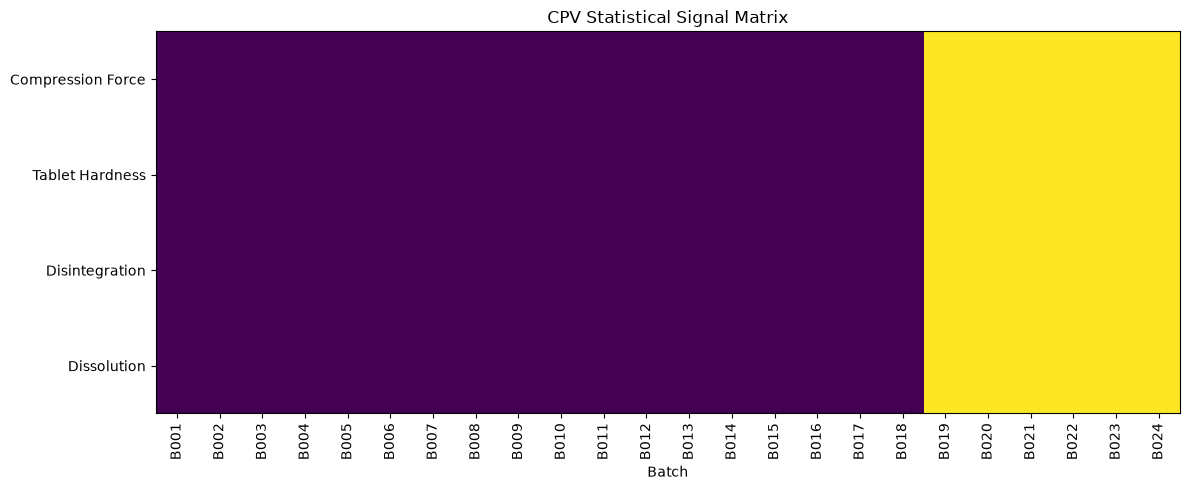

In [23]:
signal_matrix = df[
    [
        "Compression_Signal",
        "Hardness_Signal",
        "Disintegration_Signal",
        "Dissolution_Signal"
    ]
].ne("Normal").astype(int)

fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(signal_matrix.T, aspect="auto")

ax.set_xticks(range(len(df)))
ax.set_xticklabels(df["Batch_ID"], rotation=90)

ax.set_yticks(range(4))
ax.set_yticklabels([
    "Compression Force",
    "Tablet Hardness",
    "Disintegration",
    "Dissolution"
])

ax.set_xlabel("Batch")
ax.set_title("CPV Statistical Signal Matrix")

plt.tight_layout()
plt.show()

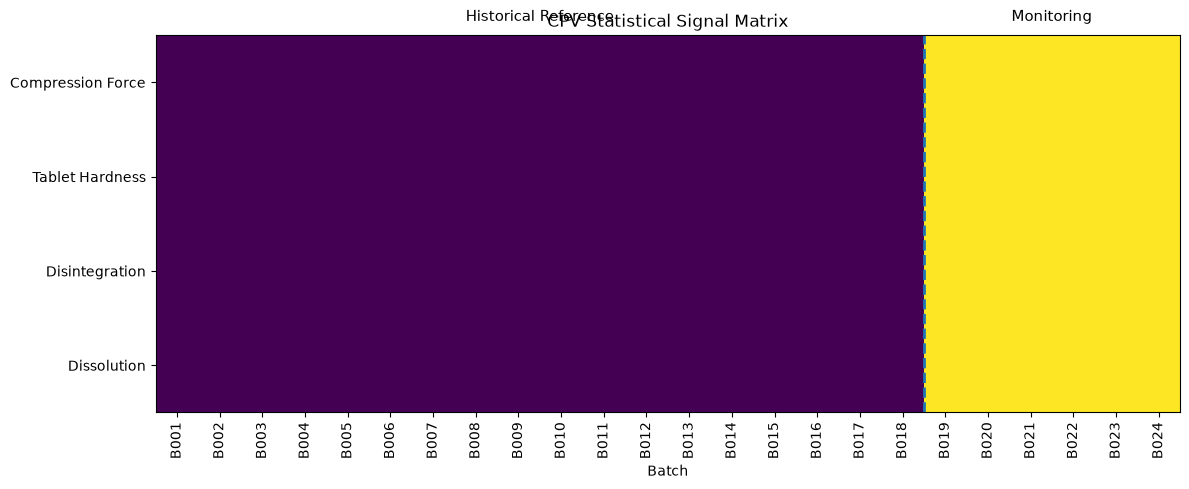

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(signal_matrix.T, aspect="auto")

ax.set_xticks(range(len(df)))
ax.set_xticklabels(df["Batch_ID"], rotation=90)

ax.set_yticks(range(4))
ax.set_yticklabels([
    "Compression Force",
    "Tablet Hardness",
    "Disintegration",
    "Dissolution"
])

# Mark transition between B018 and B019
ax.axvline(x=17.5, linestyle="--", linewidth=2)

ax.text(
    8.5, -0.65,
    "Historical Reference",
    ha="center",
    fontsize=11
)

ax.text(
    20.5, -0.65,
    "Monitoring",
    ha="center",
    fontsize=11
)

ax.set_xlabel("Batch")
ax.set_title("CPV Statistical Signal Matrix")

plt.tight_layout()
plt.show()

In [25]:
monitoring_df = df[df["Reference_Period"] == "Monitoring"]

total_monitoring = len(monitoring_df)

flagged_batches = (
    monitoring_df["CPV_Status"] == "Pass - Process Signal"
).sum()

spec_failures = (
    monitoring_df["Spec_Status"] != "Pass"
).sum()

avg_signal_count = monitoring_df["Signal_Count"].mean()

print("Monitoring Batches:", total_monitoring)
print("Batches with CPV Signals:", flagged_batches)
print("Specification Failures:", spec_failures)
print("Average Signals per Batch:", round(avg_signal_count, 1))

Monitoring Batches: 6
Batches with CPV Signals: 6
Specification Failures: 0
Average Signals per Batch: 4.0


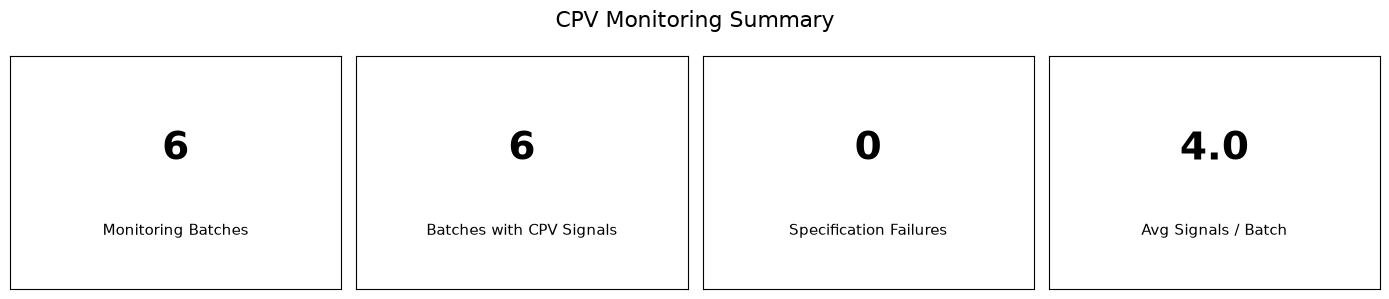

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

kpi_values = [
    total_monitoring,
    flagged_batches,
    spec_failures,
    round(avg_signal_count, 1)
]

kpi_titles = [
    "Monitoring Batches",
    "Batches with CPV Signals",
    "Specification Failures",
    "Avg Signals / Batch"
]

for ax, value, title in zip(axes, kpi_values, kpi_titles):
    ax.text(
        0.5, 0.6,
        str(value),
        ha="center",
        va="center",
        fontsize=28,
        fontweight="bold"
    )

    ax.text(
        0.5, 0.25,
        title,
        ha="center",
        va="center",
        fontsize=11
    )

    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("CPV Monitoring Summary", fontsize=16)
plt.tight_layout()
plt.show()

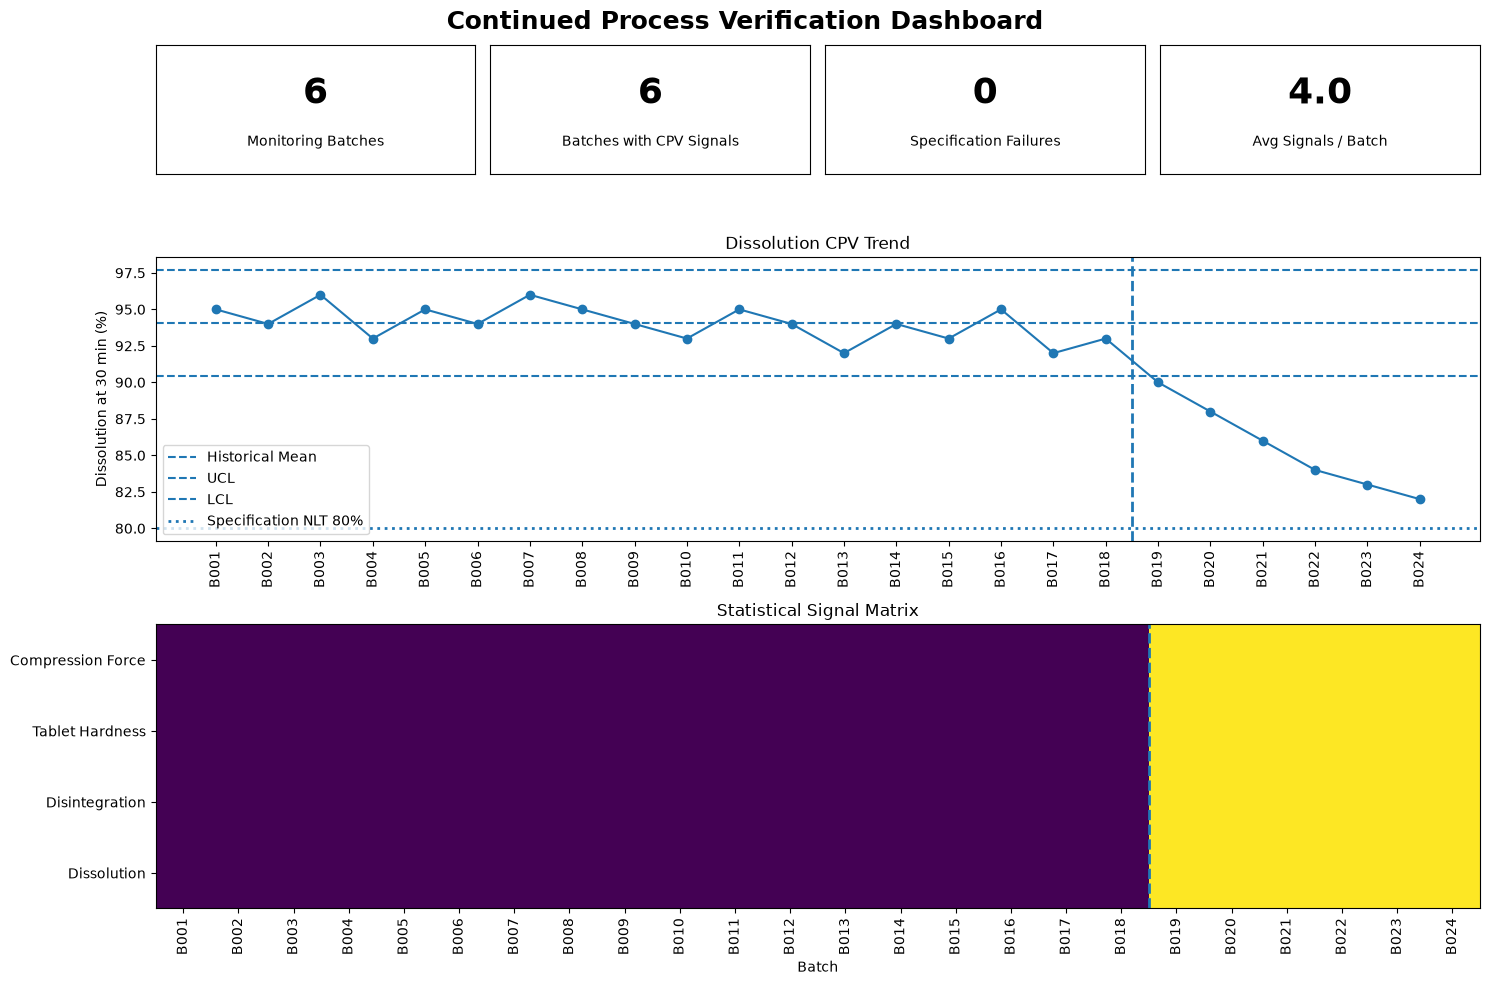

In [27]:
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(3, 4, height_ratios=[1, 2.2, 2.2])

# -------------------------------------------------
# 1. KPI CARDS
# -------------------------------------------------

kpi_values = [
    total_monitoring,
    flagged_batches,
    spec_failures,
    round(avg_signal_count, 1)
]

kpi_titles = [
    "Monitoring Batches",
    "Batches with CPV Signals",
    "Specification Failures",
    "Avg Signals / Batch"
]

for i in range(4):
    ax = fig.add_subplot(gs[0, i])

    ax.text(
        0.5, 0.62,
        str(kpi_values[i]),
        ha="center",
        va="center",
        fontsize=26,
        fontweight="bold"
    )

    ax.text(
        0.5, 0.25,
        kpi_titles[i],
        ha="center",
        va="center",
        fontsize=10
    )

    ax.set_xticks([])
    ax.set_yticks([])


# -------------------------------------------------
# 2. DISSOLUTION TREND
# -------------------------------------------------

ax1 = fig.add_subplot(gs[1, :])

ax1.plot(
    df["Batch_ID"],
    df["Dissolution_30min_pct"],
    marker="o"
)

ax1.axhline(
    historical_mean,
    linestyle="--",
    label="Historical Mean"
)

ax1.axhline(
    ucl,
    linestyle="--",
    label="UCL"
)

ax1.axhline(
    lcl,
    linestyle="--",
    label="LCL"
)

# Product specification
ax1.axhline(
    80,
    linestyle=":",
    linewidth=2,
    label="Specification NLT 80%"
)

# Historical → Monitoring boundary
ax1.axvline(
    x=17.5,
    linestyle="--",
    linewidth=2
)

ax1.set_ylabel("Dissolution at 30 min (%)")
ax1.set_title("Dissolution CPV Trend")
ax1.tick_params(axis="x", rotation=90)
ax1.legend()


# -------------------------------------------------
# 3. SIGNAL MATRIX
# -------------------------------------------------

ax2 = fig.add_subplot(gs[2, :])

ax2.imshow(
    signal_matrix.T,
    aspect="auto"
)

ax2.set_xticks(range(len(df)))
ax2.set_xticklabels(
    df["Batch_ID"],
    rotation=90
)

ax2.set_yticks(range(4))
ax2.set_yticklabels([
    "Compression Force",
    "Tablet Hardness",
    "Disintegration",
    "Dissolution"
])

ax2.axvline(
    x=17.5,
    linestyle="--",
    linewidth=2
)

ax2.set_xlabel("Batch")
ax2.set_title("Statistical Signal Matrix")


# -------------------------------------------------
# OVERALL DASHBOARD TITLE
# -------------------------------------------------

fig.suptitle(
    "Continued Process Verification Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 8. Risk Classification and Automated CPV Assessment
Apply a simple project-specific triage layer to summarize the severity of coordinated process signals. These Green/Yellow/Red/Critical labels are project rules, not regulatory categories.


In [28]:
df["Risk_Level"] = "Green"

df.loc[
    (df["Signal_Count"] >= 1) & (df["Signal_Count"] <= 2),
    "Risk_Level"
] = "Yellow"

df.loc[
    df["Signal_Count"] >= 3,
    "Risk_Level"
] = "Red"

df.loc[
    df["Spec_Status"] != "Pass",
    "Risk_Level"
] = "Critical"

df.loc[
    df["Reference_Period"] == "Monitoring",
    [
        "Batch_ID",
        "Spec_Status",
        "Signal_Count",
        "CPV_Status",
        "Risk_Level"
    ]
]

,Batch_ID,Spec_Status,Signal_Count,CPV_Status,Risk_Level
18,B019,Pass,4,Pass - Process Signal,Red
19,B020,Pass,4,Pass - Process Signal,Red
20,B021,Pass,4,Pass - Process Signal,Red
21,B022,Pass,4,Pass - Process Signal,Red
22,B023,Pass,4,Pass - Process Signal,Red
23,B024,Pass,4,Pass - Process Signal,Red


In [29]:
monitoring_df = df[df["Reference_Period"] == "Monitoring"]

red_batches = (monitoring_df["Risk_Level"] == "Red").sum()
critical_batches = (monitoring_df["Risk_Level"] == "Critical").sum()
total_monitoring = len(monitoring_df)

if critical_batches > 0:
    cpv_conclusion = (
        f"Immediate escalation recommended: "
        f"{critical_batches} monitoring batch(es) failed specification."
    )

elif red_batches >= 3:
    cpv_conclusion = (
        f"Escalation recommended: sustained multivariate process shift detected "
        f"across {red_batches} of {total_monitoring} monitoring batches "
        f"despite continued specification compliance."
    )

elif red_batches > 0:
    cpv_conclusion = (
        "Process review recommended: multiple statistical signals detected "
        "during continued process verification."
    )

else:
    cpv_conclusion = (
        "Process remains consistent with the historical reference state."
    )

print("CPV Conclusion:")
print(cpv_conclusion)

CPV Conclusion:
Escalation recommended: sustained multivariate process shift detected across 6 of 6 monitoring batches despite continued specification compliance.


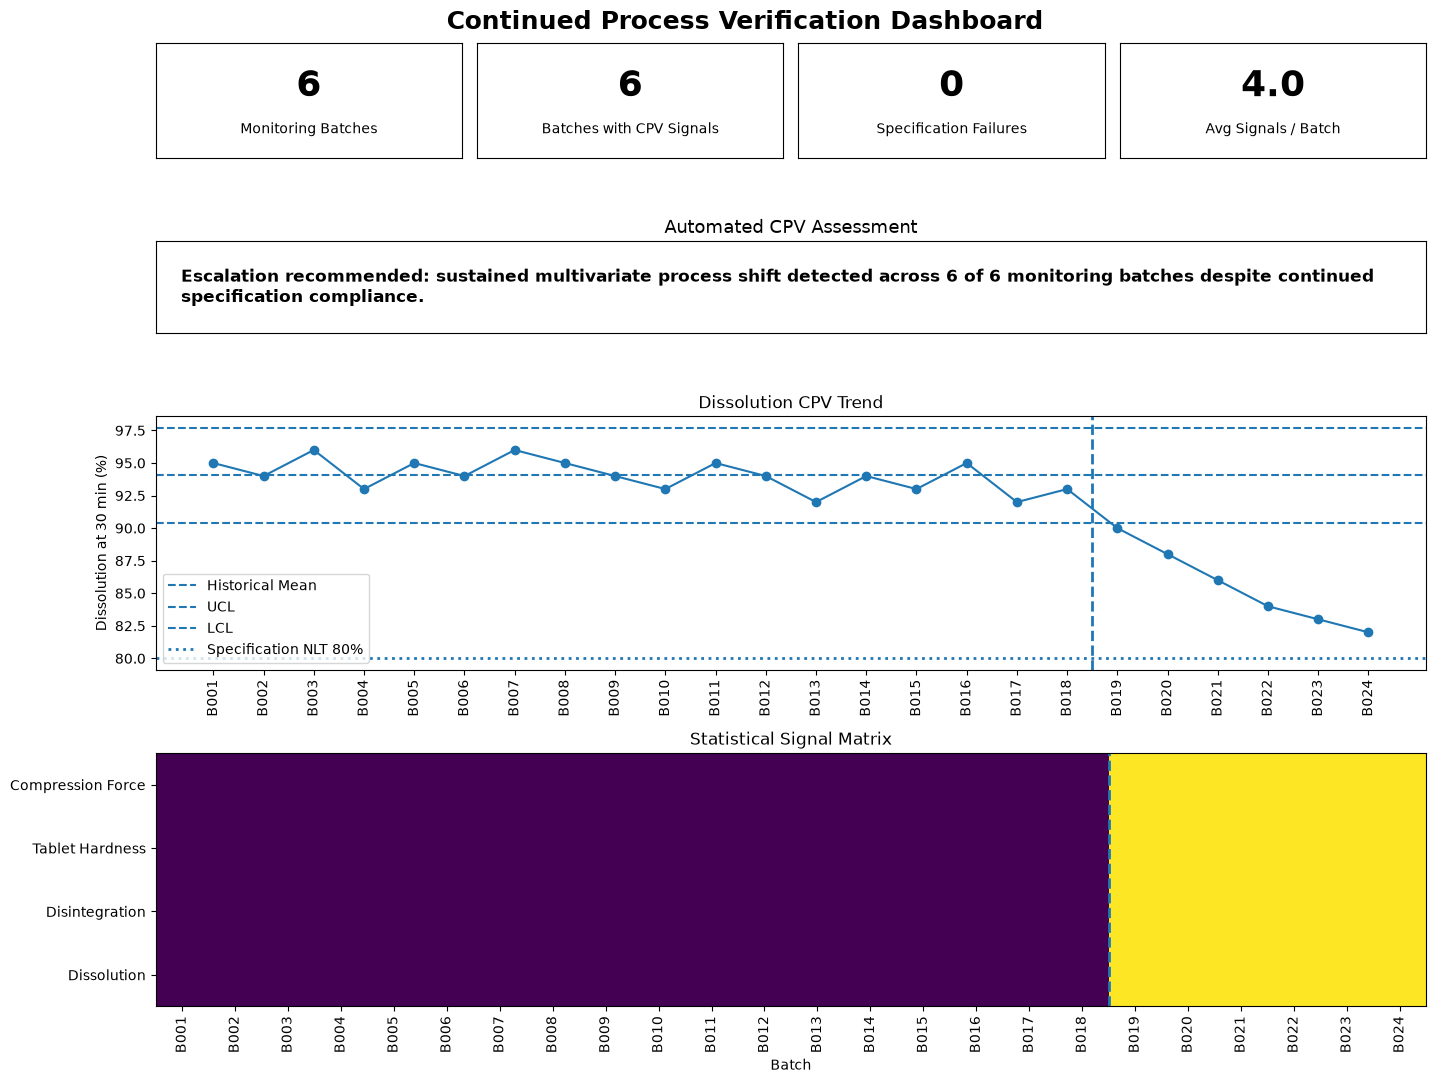

In [30]:
fig = plt.figure(figsize=(15, 11))
gs = fig.add_gridspec(
    4, 4,
    height_ratios=[1, 0.8, 2.2, 2.2]
)

# -------------------------------------------------
# 1. KPI CARDS
# -------------------------------------------------

kpi_values = [
    total_monitoring,
    flagged_batches,
    spec_failures,
    round(avg_signal_count, 1)
]

kpi_titles = [
    "Monitoring Batches",
    "Batches with CPV Signals",
    "Specification Failures",
    "Avg Signals / Batch"
]

for i in range(4):
    ax = fig.add_subplot(gs[0, i])

    ax.text(
        0.5, 0.62,
        str(kpi_values[i]),
        ha="center",
        va="center",
        fontsize=26,
        fontweight="bold"
    )

    ax.text(
        0.5, 0.25,
        kpi_titles[i],
        ha="center",
        va="center",
        fontsize=10
    )

    ax.set_xticks([])
    ax.set_yticks([])


# -------------------------------------------------
# 2. AUTOMATED CPV CONCLUSION
# -------------------------------------------------

ax0 = fig.add_subplot(gs[1, :])

ax0.text(
    0.02,
    0.5,
    cpv_conclusion,
    ha="left",
    va="center",
    fontsize=12,
    fontweight="bold",
    wrap=True
)

ax0.set_title("Automated CPV Assessment", fontsize=13)
ax0.set_xticks([])
ax0.set_yticks([])


# -------------------------------------------------
# 3. DISSOLUTION TREND
# -------------------------------------------------

ax1 = fig.add_subplot(gs[2, :])

ax1.plot(
    df["Batch_ID"],
    df["Dissolution_30min_pct"],
    marker="o"
)

ax1.axhline(
    historical_mean,
    linestyle="--",
    label="Historical Mean"
)

ax1.axhline(
    ucl,
    linestyle="--",
    label="UCL"
)

ax1.axhline(
    lcl,
    linestyle="--",
    label="LCL"
)

ax1.axhline(
    80,
    linestyle=":",
    linewidth=2,
    label="Specification NLT 80%"
)

ax1.axvline(
    x=17.5,
    linestyle="--",
    linewidth=2
)

ax1.set_ylabel("Dissolution at 30 min (%)")
ax1.set_title("Dissolution CPV Trend")
ax1.tick_params(axis="x", rotation=90)
ax1.legend()


# -------------------------------------------------
# 4. SIGNAL MATRIX
# -------------------------------------------------

ax2 = fig.add_subplot(gs[3, :])

ax2.imshow(
    signal_matrix.T,
    aspect="auto"
)

ax2.set_xticks(range(len(df)))
ax2.set_xticklabels(
    df["Batch_ID"],
    rotation=90
)

ax2.set_yticks(range(4))
ax2.set_yticklabels([
    "Compression Force",
    "Tablet Hardness",
    "Disintegration",
    "Dissolution"
])

ax2.axvline(
    x=17.5,
    linestyle="--",
    linewidth=2
)

ax2.set_xlabel("Batch")
ax2.set_title("Statistical Signal Matrix")


# -------------------------------------------------
# DASHBOARD TITLE
# -------------------------------------------------

fig.suptitle(
    "Continued Process Verification Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 9. Standardized Shift Analysis and Investigation Prioritization
Standardize monitoring-batch departures from the historical reference using z-scores, quantify shift severity, and separate upstream investigation variables from intermediate responses and the CQA.


In [31]:
root_cause_vars = [
    "Compression_Force_kN",
    "Tablet_Hardness_kp",
    "Disintegration_min",
    "API_PSD_D90_um"
]

historical_df = df[df["Reference_Period"] == "Historical"]
monitoring_df = df[df["Reference_Period"] == "Monitoring"]

root_cause_summary = []

for var in root_cause_vars:
    
    hist_mean = historical_df[var].mean()
    monitoring_mean = monitoring_df[var].mean()
    
    pct_change = ((monitoring_mean - hist_mean) / hist_mean) * 100
    
    correlation = monitoring_df[
        [var, "Dissolution_30min_pct"]
    ].corr().iloc[0, 1]
    
    root_cause_summary.append({
        "Parameter": var,
        "Historical_Mean": round(hist_mean, 2),
        "Monitoring_Mean": round(monitoring_mean, 2),
        "Percent_Change": round(pct_change, 1),
        "Correlation_with_Dissolution": round(correlation, 3)
    })

root_cause_summary = pd.DataFrame(root_cause_summary)

root_cause_summary

,Parameter,Historical_Mean,Monitoring_Mean,Percent_Change,Correlation_with_Dissolution
0,Compression_Force_kN,10.82,12.93,19.6,-0.991
1,Tablet_Hardness_kp,7.13,8.62,20.9,-0.985
2,Disintegration_min,6.52,8.32,27.5,-0.988
3,API_PSD_D90_um,75.22,91.00,21.0,-0.725


In [32]:
monitoring_df[
    [
        "API_PSD_D90_um",
        "Compression_Force_kN",
        "Tablet_Hardness_kp",
        "Disintegration_min",
        "Dissolution_30min_pct"
    ]
].corr()

,API_PSD_D90_um,Compression_Force_kN,Tablet_Hardness_kp,Disintegration_min,Dissolution_30min_pct
API_PSD_D90_um,1.000000,0.668350,0.704119,0.724008,-0.725476
Compression_Force_kN,0.668350,1.000000,0.995974,0.993849,-0.991293
Tablet_Hardness_kp,0.704119,0.995974,1.000000,0.998611,-0.985157
Disintegration_min,0.724008,0.993849,0.998611,1.000000,-0.988426
Dissolution_30min_pct,-0.725476,-0.991293,-0.985157,-0.988426,1.000000


In [33]:
variables = [
    "API_PSD_D90_um",
    "Compression_Force_kN",
    "Tablet_Hardness_kp",
    "Disintegration_min",
    "Dissolution_30min_pct"
]

hist_means = historical_df[variables].mean()
hist_stds = historical_df[variables].std()

monitoring_z = (
    monitoring_df[variables] - hist_means
) / hist_stds

monitoring_z.insert(
    0,
    "Batch_ID",
    monitoring_df["Batch_ID"].values
)

monitoring_z.round(2)

,Batch_ID,API_PSD_D90_um,Compression_Force_kN,Tablet_Hardness_kp,Disintegration_min,Dissolution_30min_pct
18,B019,6.60,4.90,3.93,3.83,-3.35
19,B020,7.05,5.48,5.29,5.58,-5.00
20,B021,6.60,6.07,6.19,6.89,-6.65
21,B022,7.50,6.36,7.09,8.64,-8.30
22,B023,7.05,6.94,8.44,10.39,-9.13
23,B024,7.50,7.23,9.34,11.70,-9.95


In [34]:
z_columns = [
    "API_PSD_D90_um",
    "Compression_Force_kN",
    "Tablet_Hardness_kp",
    "Disintegration_min",
    "Dissolution_30min_pct"
]

shift_severity = (
    monitoring_z[z_columns]
    .abs()
    .mean()
    .sort_values(ascending=False)
)

shift_severity

Disintegration_min       7.837698
Dissolution_30min_pct    7.062944
API_PSD_D90_um           7.051429
Tablet_Hardness_kp       6.713589
Compression_Force_kN     6.163391
dtype: float64

In [35]:
investigation_table = pd.DataFrame({
    "Parameter": [
        "API PSD D90",
        "Compression Force",
        "Tablet Hardness",
        "Disintegration",
        "Dissolution"
    ],
    
    "Process_Role": [
        "Material Attribute",
        "Process Parameter",
        "Intermediate Response",
        "Intermediate Response",
        "CQA"
    ],
    
    "Avg_Absolute_Z": [
        shift_severity["API_PSD_D90_um"],
        shift_severity["Compression_Force_kN"],
        shift_severity["Tablet_Hardness_kp"],
        shift_severity["Disintegration_min"],
        shift_severity["Dissolution_30min_pct"]
    ],
    
    "Correlation_with_Dissolution": [
        -0.725,
        -0.991,
        -0.985,
        -0.988,
        1.000
    ]
})

investigation_table.round(2)

,Parameter,Process_Role,Avg_Absolute_Z,Correlation_with_Dissolution
0,API PSD D90,Material Attribute,7.05,-0.72
1,Compression Force,Process Parameter,6.16,-0.99
2,Tablet Hardness,Intermediate Response,6.71,-0.98
3,Disintegration,Intermediate Response,7.84,-0.99
4,Dissolution,CQA,7.06,1.00


In [36]:
investigation_table["Investigation_Priority"] = [
    "High",
    "High",
    "Supporting Evidence",
    "Supporting Evidence",
    "Outcome / CQA"
]

investigation_table["Interpretation"] = [
    "Investigate API lot, PSD, milling, sampling, and material changes",
    "Investigate compression settings and compression-process changes",
    "Supporting response consistent with increased compression",
    "Supporting response associated with declining dissolution",
    "CQA showing sustained deterioration"
]

investigation_table

,Parameter,Process_Role,Avg_Absolute_Z,Correlation_with_Dissolution,Investigation_Priority,Interpretation
0,API PSD D90,Material Attribute,7.051429,-0.725,High,"Investigate API lot, PSD, milling, sampling, a..."
1,Compression Force,Process Parameter,6.163391,-0.991,High,Investigate compression settings and compressi...
2,Tablet Hardness,Intermediate Response,6.713589,-0.985,Supporting Evidence,Supporting response consistent with increased ...
3,Disintegration,Intermediate Response,7.837698,-0.988,Supporting Evidence,Supporting response associated with declining ...
4,Dissolution,CQA,7.062944,1.000,Outcome / CQA,CQA showing sustained deterioration


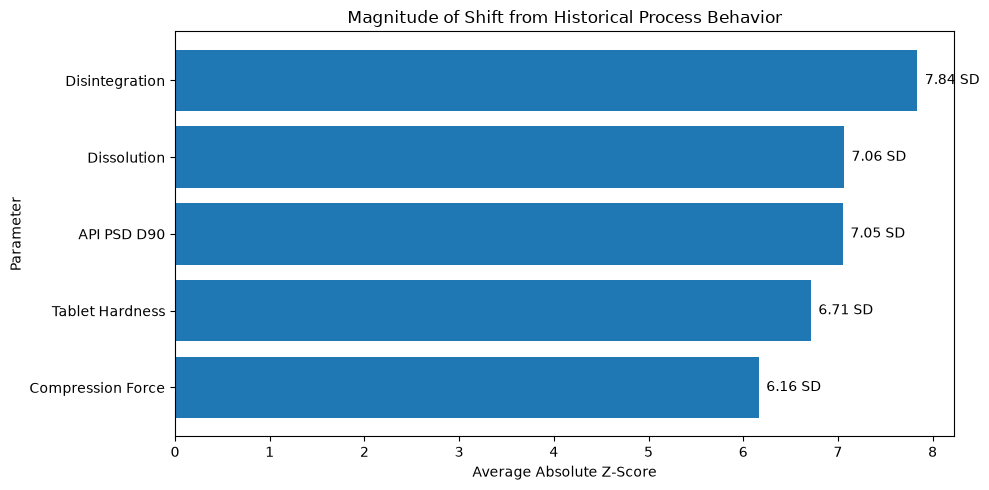

In [37]:
plot_df = investigation_table.sort_values(
    "Avg_Absolute_Z",
    ascending=True
)

plt.figure(figsize=(10, 5))

plt.barh(
    plot_df["Parameter"],
    plot_df["Avg_Absolute_Z"]
)

plt.xlabel("Average Absolute Z-Score")
plt.ylabel("Parameter")
plt.title("Magnitude of Shift from Historical Process Behavior")

for i, value in enumerate(plot_df["Avg_Absolute_Z"]):
    plt.text(
        value + 0.08,
        i,
        f"{value:.2f} SD",
        va="center"
    )

plt.tight_layout()
plt.show()

## 10. Final Integrated CPV Dashboard
Present management KPIs, automated assessment, dissolution trend, standardized shift severity, and the multivariate signal matrix in one view.


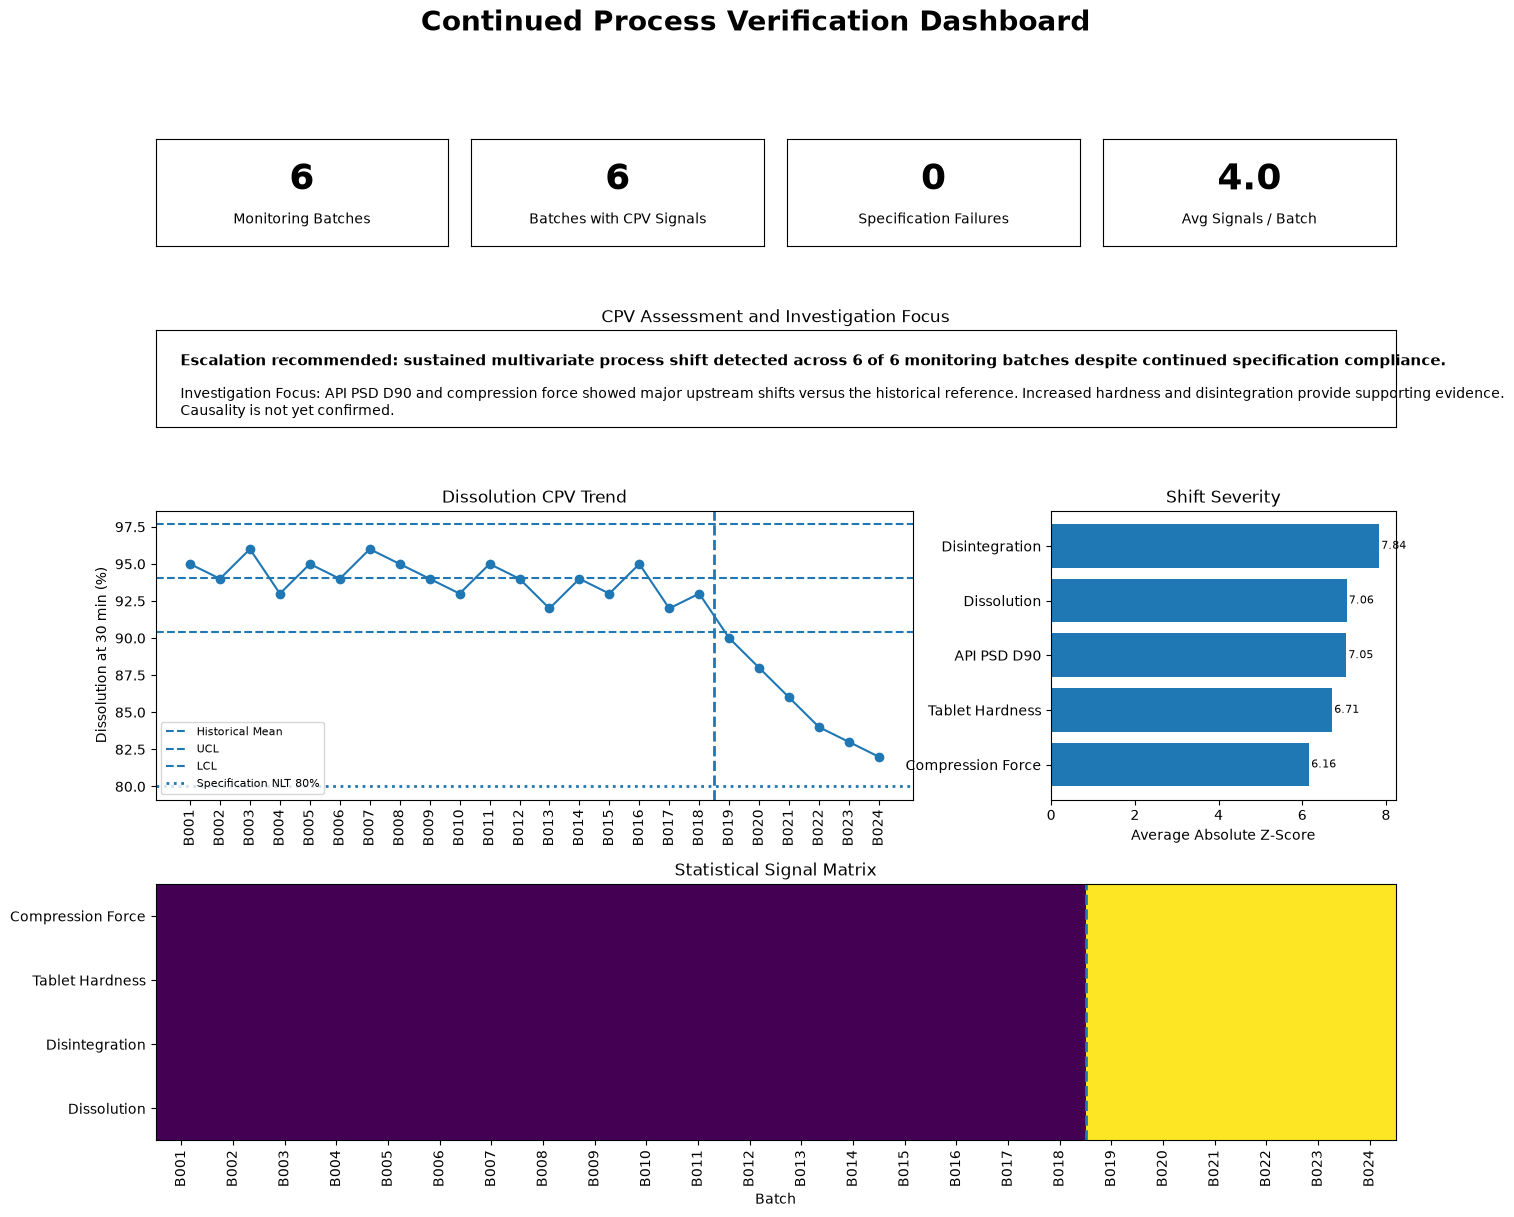

In [38]:
driver_message = (
    "Investigation Focus: API PSD D90 and compression force showed major "
    "upstream shifts versus the historical reference. Increased hardness "
    "and disintegration provide supporting evidence. Causality is not yet confirmed."
)

fig = plt.figure(figsize=(16, 13))

outer = fig.add_gridspec(
    4, 1,
    height_ratios=[1, 0.9, 2.7, 2.4],
    hspace=0.45
)

# =================================================
# 1. KPI CARDS
# =================================================

kpi_grid = outer[0].subgridspec(1, 4, wspace=0.08)

kpi_values = [
    total_monitoring,
    flagged_batches,
    spec_failures,
    round(avg_signal_count, 1)
]

kpi_titles = [
    "Monitoring Batches",
    "Batches with CPV Signals",
    "Specification Failures",
    "Avg Signals / Batch"
]

for i in range(4):
    ax = fig.add_subplot(kpi_grid[0, i])

    ax.text(
        0.5, 0.62,
        str(kpi_values[i]),
        ha="center",
        va="center",
        fontsize=26,
        fontweight="bold"
    )

    ax.text(
        0.5, 0.25,
        kpi_titles[i],
        ha="center",
        va="center",
        fontsize=10
    )

    ax.set_xticks([])
    ax.set_yticks([])


# =================================================
# 2. AUTOMATED ASSESSMENT + INVESTIGATION FOCUS
# =================================================

ax_text = fig.add_subplot(outer[1])

ax_text.text(
    0.02, 0.68,
    cpv_conclusion,
    fontsize=11,
    fontweight="bold",
    va="center",
    wrap=True
)

ax_text.text(
    0.02, 0.25,
    driver_message,
    fontsize=10,
    va="center",
    wrap=True
)

ax_text.set_title("CPV Assessment and Investigation Focus")
ax_text.set_xticks([])
ax_text.set_yticks([])


# =================================================
# 3. DISSOLUTION TREND + SHIFT SEVERITY
# =================================================

middle = outer[2].subgridspec(
    1, 2,
    width_ratios=[2.2, 1],
    wspace=0.25
)

# Dissolution trend
ax1 = fig.add_subplot(middle[0, 0])

ax1.plot(
    df["Batch_ID"],
    df["Dissolution_30min_pct"],
    marker="o"
)

ax1.axhline(
    historical_mean,
    linestyle="--",
    label="Historical Mean"
)

ax1.axhline(
    ucl,
    linestyle="--",
    label="UCL"
)

ax1.axhline(
    lcl,
    linestyle="--",
    label="LCL"
)

ax1.axhline(
    80,
    linestyle=":",
    linewidth=2,
    label="Specification NLT 80%"
)

ax1.axvline(
    x=17.5,
    linestyle="--",
    linewidth=2
)

ax1.set_ylabel("Dissolution at 30 min (%)")
ax1.set_title("Dissolution CPV Trend")
ax1.tick_params(axis="x", rotation=90)
ax1.legend(fontsize=8)


# Shift severity
ax_shift = fig.add_subplot(middle[0, 1])

plot_df = investigation_table.sort_values(
    "Avg_Absolute_Z",
    ascending=True
)

ax_shift.barh(
    plot_df["Parameter"],
    plot_df["Avg_Absolute_Z"]
)

ax_shift.set_xlabel("Average Absolute Z-Score")
ax_shift.set_title("Shift Severity")

for i, value in enumerate(plot_df["Avg_Absolute_Z"]):
    ax_shift.text(
        value + 0.05,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=8
    )


# =================================================
# 4. SIGNAL MATRIX
# =================================================

ax2 = fig.add_subplot(outer[3])

ax2.imshow(
    signal_matrix.T,
    aspect="auto"
)

ax2.set_xticks(range(len(df)))
ax2.set_xticklabels(
    df["Batch_ID"],
    rotation=90
)

ax2.set_yticks(range(4))
ax2.set_yticklabels([
    "Compression Force",
    "Tablet Hardness",
    "Disintegration",
    "Dissolution"
])

ax2.axvline(
    x=17.5,
    linestyle="--",
    linewidth=2
)

ax2.set_xlabel("Batch")
ax2.set_title("Statistical Signal Matrix")


# =================================================
# DASHBOARD TITLE
# =================================================

fig.suptitle(
    "Continued Process Verification Dashboard",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

plt.show()

## 11. Export
Save the final dashboard as a high-resolution PNG for reporting and portfolio use.


In [39]:
fig.savefig(
    "CPV_Dashboard_V1.png",
    dpi=300,
    bbox_inches="tight"
)

# 12. CPV Dashboard V2
## Advanced Statistical Monitoring

V2 extends the baseline CPV dashboard with:
1. SPC run-rule detection
2. Change-point detection
3. Automated statistical alerts

In [40]:
spc_df = df.copy()
spc_df.columns.tolist()

['Batch_ID',
 'Manufacture_Date',
 'Product',
 'Reference_Period',
 'API_Lot',
 'API_PSD_D90_um',
 'Compression_Force_kN',
 'Tablet_Hardness_kp',
 'Thickness_mm',
 'Tablet_Weight_mg',
 'Disintegration_min',
 'Dissolution_30min_pct',
 'Spec_Status',
 'Control_Status',
 'Dissolution_Signal',
 'Compression_Signal',
 'Hardness_Signal',
 'Disintegration_Signal',
 'Signal_Count',
 'CPV_Status',
 'Risk_Level']

In [41]:
[col for col in spc_df.columns if "z" in col.lower()]

[]

In [42]:
spc_df.columns.tolist()

['Batch_ID',
 'Manufacture_Date',
 'Product',
 'Reference_Period',
 'API_Lot',
 'API_PSD_D90_um',
 'Compression_Force_kN',
 'Tablet_Hardness_kp',
 'Thickness_mm',
 'Tablet_Weight_mg',
 'Disintegration_min',
 'Dissolution_30min_pct',
 'Spec_Status',
 'Control_Status',
 'Dissolution_Signal',
 'Compression_Signal',
 'Hardness_Signal',
 'Disintegration_Signal',
 'Signal_Count',
 'CPV_Status',
 'Risk_Level']

In [43]:
spc_df['Reference_Period'].value_counts(dropna=False)

Reference_Period
Historical    18
Monitoring     6
Name: count, dtype: int64

In [44]:
# Variables to monitor
cpv_vars = [
    'API_PSD_D90_um',
    'Compression_Force_kN',
    'Tablet_Hardness_kp',
    'Thickness_mm',
    'Tablet_Weight_mg',
    'Disintegration_min',
    'Dissolution_30min_pct'
]

# Historical reference data
historical = spc_df[spc_df['Reference_Period'] == 'Historical']

# Calculate Z-scores using HISTORICAL mean and standard deviation
for var in cpv_vars:
    mean_ref = historical[var].mean()
    std_ref = historical[var].std()

    spc_df[var + '_Z'] = (spc_df[var] - mean_ref) / std_ref

# Show monitoring batches and their Z-scores
z_cols = [var + '_Z' for var in cpv_vars]

spc_df.loc[
    spc_df['Reference_Period'] == 'Monitoring',
    ['Batch_ID'] + z_cols
]

,Batch_ID,API_PSD_D90_um_Z,Compression_Force_kN_Z,Tablet_Hardness_kp_Z,Thickness_mm_Z,Tablet_Weight_mg_Z,Disintegration_min_Z,Dissolution_30min_pct_Z
18,B019,6.604508,4.901595,3.932961,-0.293016,0.360182,3.833921,-3.348019
19,B020,7.051429,5.483962,5.285699,-1.172065,-0.288146,5.581024,-4.999097
20,B021,6.604508,6.066330,6.187524,0.586033,1.008511,6.891351,-6.650174
21,B022,7.498351,6.357514,7.089350,-0.293016,-0.936474,8.638454,-8.301252
22,B023,7.051429,6.939882,8.442088,1.465082,0.360182,10.385557,-9.126791
23,B024,7.498351,7.231065,9.343913,0.586033,-0.288146,11.695884,-9.952330


In [45]:
spc_df['API_PSD_Rule1'] = spc_df['API_PSD_D90_um_Z'].abs() > 3

spc_df.loc[
    spc_df['Reference_Period'] == 'Monitoring',
    ['Batch_ID', 'API_PSD_D90_um_Z', 'API_PSD_Rule1']
]

,Batch_ID,API_PSD_D90_um_Z,API_PSD_Rule1
18,B019,6.604508,True
19,B020,7.051429,True
20,B021,6.604508,True
21,B022,7.498351,True
22,B023,7.051429,True
23,B024,7.498351,True


In [46]:
# Nelson Rule 1 — apply to all CPV variables
# One point beyond ±3 historical standard deviations

for var in cpv_vars:
    z_col = var + '_Z'
    rule_col = var + '_Rule1'

    spc_df[rule_col] = spc_df[z_col].abs() > 3

print("Rule 1 columns created for all CPV variables")

Rule 1 columns created for all CPV variables


In [47]:
rule1_cols = [var + '_Rule1' for var in cpv_vars]

spc_df.loc[
    spc_df['Reference_Period'] == 'Monitoring',
    ['Batch_ID'] + rule1_cols
]

,Batch_ID,API_PSD_D90_um_Rule1,Compression_Force_kN_Rule1,Tablet_Hardness_kp_Rule1,Thickness_mm_Rule1,Tablet_Weight_mg_Rule1,Disintegration_min_Rule1,Dissolution_30min_pct_Rule1
18,B019,True,True,True,False,False,True,True
19,B020,True,True,True,False,False,True,True
20,B021,True,True,True,False,False,True,True
21,B022,True,True,True,False,False,True,True
22,B023,True,True,True,False,False,True,True
23,B024,True,True,True,False,False,True,True


In [48]:
spc_df['Rule1_Signal_Count'] = spc_df[rule1_cols].sum(axis=1)

spc_df.loc[
    spc_df['Reference_Period'] == 'Monitoring',
    ['Batch_ID', 'Rule1_Signal_Count']
]

,Batch_ID,Rule1_Signal_Count
18,B019,5
19,B020,5
20,B021,5
21,B022,5
22,B023,5
23,B024,5


In [49]:
# Nelson Rule 2:
# 9 consecutive points on the same side of the centerline

for var in cpv_vars:
    z_col = var + '_Z'
    rule_col = var + '_Rule2'

    above_center = spc_df[z_col] > 0
    below_center = spc_df[z_col] < 0

    spc_df[rule_col] = (
        above_center.rolling(window=9, min_periods=9).sum().eq(9)
        |
        below_center.rolling(window=9, min_periods=9).sum().eq(9)
    )

In [50]:
# Nelson Rule 2:
# 9 consecutive MONITORING points on the same side of the centerline

for var in cpv_vars:
    z_col = var + '_Z'
    rule_col = var + '_Rule2'

    spc_df[rule_col] = False

    monitoring_z = spc_df.loc[
        spc_df['Reference_Period'] == 'Monitoring',
        z_col
    ]

    above_center = monitoring_z > 0
    below_center = monitoring_z < 0

    rule2_result = (
        above_center.rolling(window=9, min_periods=9).sum().eq(9)
        |
        below_center.rolling(window=9, min_periods=9).sum().eq(9)
    )

    spc_df.loc[
        spc_df['Reference_Period'] == 'Monitoring',
        rule_col
    ] = rule2_result

In [51]:
rule2_cols = [var + '_Rule2' for var in cpv_vars]

In [52]:
spc_df.loc[
    spc_df['Reference_Period'] == 'Monitoring',
    ['Batch_ID'] + rule2_cols
]

,Batch_ID,API_PSD_D90_um_Rule2,Compression_Force_kN_Rule2,Tablet_Hardness_kp_Rule2,Thickness_mm_Rule2,Tablet_Weight_mg_Rule2,Disintegration_min_Rule2,Dissolution_30min_pct_Rule2
18,B019,False,False,False,False,False,False,False
19,B020,False,False,False,False,False,False,False
20,B021,False,False,False,False,False,False,False
21,B022,False,False,False,False,False,False,False
22,B023,False,False,False,False,False,False,False
23,B024,False,False,False,False,False,False,False


In [53]:
# Nelson Rule 3:
# 6 consecutive MONITORING points continuously increasing or decreasing

for var in cpv_vars:
    z_col = var + '_Z'
    rule_col = var + '_Rule3'

    spc_df[rule_col] = False

    monitoring_z = spc_df.loc[
        spc_df['Reference_Period'] == 'Monitoring',
        z_col
    ]

    differences = monitoring_z.diff()

    increasing = differences > 0
    decreasing = differences < 0

    rule3_result = (
        increasing.rolling(window=5, min_periods=5).sum().eq(5)
        |
        decreasing.rolling(window=5, min_periods=5).sum().eq(5)
    )

    spc_df.loc[
        spc_df['Reference_Period'] == 'Monitoring',
        rule_col
    ] = rule3_result

In [54]:
rule3_cols = [var + '_Rule3' for var in cpv_vars]

spc_df.loc[
    spc_df['Reference_Period'] == 'Monitoring',
    ['Batch_ID'] + rule3_cols
]

,Batch_ID,API_PSD_D90_um_Rule3,Compression_Force_kN_Rule3,Tablet_Hardness_kp_Rule3,Thickness_mm_Rule3,Tablet_Weight_mg_Rule3,Disintegration_min_Rule3,Dissolution_30min_pct_Rule3
18,B019,False,False,False,False,False,False,False
19,B020,False,False,False,False,False,False,False
20,B021,False,False,False,False,False,False,False
21,B022,False,False,False,False,False,False,False
22,B023,False,False,False,False,False,False,False
23,B024,False,True,True,False,False,True,True


In [55]:
# Nelson Rule 4:
# 14 consecutive MONITORING points alternating up and down

for var in cpv_vars:
    z_col = var + '_Z'
    rule_col = var + '_Rule4'

    spc_df[rule_col] = False

    monitoring_z = spc_df.loc[
        spc_df['Reference_Period'] == 'Monitoring',
        z_col
    ]

    differences = monitoring_z.diff()

    # True when direction reverses from previous movement
    alternating = (differences * differences.shift(1)) < 0

    # 14 points require 12 consecutive direction reversals
    rule4_result = (
        alternating
        .rolling(window=12, min_periods=12)
        .sum()
        .eq(12)
    )

    spc_df.loc[
        spc_df['Reference_Period'] == 'Monitoring',
        rule_col
    ] = rule4_result

In [56]:
rule4_cols = [var + '_Rule4' for var in cpv_vars]

spc_df.loc[
    spc_df['Reference_Period'] == 'Monitoring',
    ['Batch_ID'] + rule4_cols
]

,Batch_ID,API_PSD_D90_um_Rule4,Compression_Force_kN_Rule4,Tablet_Hardness_kp_Rule4,Thickness_mm_Rule4,Tablet_Weight_mg_Rule4,Disintegration_min_Rule4,Dissolution_30min_pct_Rule4
18,B019,False,False,False,False,False,False,False
19,B020,False,False,False,False,False,False,False
20,B021,False,False,False,False,False,False,False
21,B022,False,False,False,False,False,False,False
22,B023,False,False,False,False,False,False,False
23,B024,False,False,False,False,False,False,False


In [57]:
# Nelson Rule 5:
# 2 of 3 consecutive MONITORING points beyond ±2 sigma
# on the same side of the centerline

for var in cpv_vars:
    z_col = var + '_Z'
    rule_col = var + '_Rule5'

    spc_df[rule_col] = False

    monitoring_z = spc_df.loc[
        spc_df['Reference_Period'] == 'Monitoring',
        z_col
    ]

    above_2sigma = monitoring_z > 2
    below_2sigma = monitoring_z < -2

    rule5_result = (
        above_2sigma.rolling(window=3, min_periods=3).sum().ge(2)
        |
        below_2sigma.rolling(window=3, min_periods=3).sum().ge(2)
    )

    spc_df.loc[
        spc_df['Reference_Period'] == 'Monitoring',
        rule_col
    ] = rule5_result

In [58]:
rule5_cols = [var + '_Rule5' for var in cpv_vars]

spc_df.loc[
    spc_df['Reference_Period'] == 'Monitoring',
    ['Batch_ID'] + rule5_cols
]

,Batch_ID,API_PSD_D90_um_Rule5,Compression_Force_kN_Rule5,Tablet_Hardness_kp_Rule5,Thickness_mm_Rule5,Tablet_Weight_mg_Rule5,Disintegration_min_Rule5,Dissolution_30min_pct_Rule5
18,B019,False,False,False,False,False,False,False
19,B020,False,False,False,False,False,False,False
20,B021,True,True,True,False,False,True,True
21,B022,True,True,True,False,False,True,True
22,B023,True,True,True,False,False,True,True
23,B024,True,True,True,False,False,True,True


In [59]:
# Nelson Rule 6:
# 4 of 5 consecutive MONITORING points beyond ±1 sigma
# on the same side of the centerline

for var in cpv_vars:
    z_col = var + '_Z'
    rule_col = var + '_Rule6'

    spc_df[rule_col] = False

    monitoring_z = spc_df.loc[
        spc_df['Reference_Period'] == 'Monitoring',
        z_col
    ]

    above_1sigma = monitoring_z > 1
    below_1sigma = monitoring_z < -1

    rule6_result = (
        above_1sigma.rolling(window=5, min_periods=5).sum().ge(4)
        |
        below_1sigma.rolling(window=5, min_periods=5).sum().ge(4)
    )

    spc_df.loc[
        spc_df['Reference_Period'] == 'Monitoring',
        rule_col
    ] = rule6_result

In [60]:
rule6_cols = [var + '_Rule6' for var in cpv_vars]

spc_df.loc[
    spc_df['Reference_Period'] == 'Monitoring',
    ['Batch_ID'] + rule6_cols
]

,Batch_ID,API_PSD_D90_um_Rule6,Compression_Force_kN_Rule6,Tablet_Hardness_kp_Rule6,Thickness_mm_Rule6,Tablet_Weight_mg_Rule6,Disintegration_min_Rule6,Dissolution_30min_pct_Rule6
18,B019,False,False,False,False,False,False,False
19,B020,False,False,False,False,False,False,False
20,B021,False,False,False,False,False,False,False
21,B022,False,False,False,False,False,False,False
22,B023,True,True,True,False,False,True,True
23,B024,True,True,True,False,False,True,True


In [61]:
# Nelson Rule 7:
# 15 consecutive MONITORING points within ±1 sigma

for var in cpv_vars:
    z_col = var + '_Z'
    rule_col = var + '_Rule7'

    spc_df[rule_col] = False

    monitoring_z = spc_df.loc[
        spc_df['Reference_Period'] == 'Monitoring',
        z_col
    ]

    within_1sigma = monitoring_z.abs() < 1

    rule7_result = (
        within_1sigma
        .rolling(window=15, min_periods=15)
        .sum()
        .eq(15)
    )

    spc_df.loc[
        spc_df['Reference_Period'] == 'Monitoring',
        rule_col
    ] = rule7_result

In [62]:
rule7_cols = [var + '_Rule7' for var in cpv_vars]

spc_df.loc[
    spc_df['Reference_Period'] == 'Monitoring',
    ['Batch_ID'] + rule7_cols
]

,Batch_ID,API_PSD_D90_um_Rule7,Compression_Force_kN_Rule7,Tablet_Hardness_kp_Rule7,Thickness_mm_Rule7,Tablet_Weight_mg_Rule7,Disintegration_min_Rule7,Dissolution_30min_pct_Rule7
18,B019,False,False,False,False,False,False,False
19,B020,False,False,False,False,False,False,False
20,B021,False,False,False,False,False,False,False
21,B022,False,False,False,False,False,False,False
22,B023,False,False,False,False,False,False,False
23,B024,False,False,False,False,False,False,False


In [63]:
# Nelson Rule 8:
# 8 consecutive MONITORING points outside ±1 sigma,
# with points on both sides of the centerline

for var in cpv_vars:
    z_col = var + '_Z'
    rule_col = var + '_Rule8'

    spc_df[rule_col] = False

    monitoring_z = spc_df.loc[
        spc_df['Reference_Period'] == 'Monitoring',
        z_col
    ]

    outside_1sigma = monitoring_z.abs() > 1

    eight_outside = (
        outside_1sigma
        .rolling(window=8, min_periods=8)
        .sum()
        .eq(8)
    )

    has_positive = (
        (monitoring_z > 1)
        .rolling(window=8, min_periods=8)
        .sum()
        .gt(0)
    )

    has_negative = (
        (monitoring_z < -1)
        .rolling(window=8, min_periods=8)
        .sum()
        .gt(0)
    )

    rule8_result = eight_outside & has_positive & has_negative

    spc_df.loc[
        spc_df['Reference_Period'] == 'Monitoring',
        rule_col
    ] = rule8_result

In [64]:
rule8_cols = [var + '_Rule8' for var in cpv_vars]

spc_df.loc[
    spc_df['Reference_Period'] == 'Monitoring',
    ['Batch_ID'] + rule8_cols
]

,Batch_ID,API_PSD_D90_um_Rule8,Compression_Force_kN_Rule8,Tablet_Hardness_kp_Rule8,Thickness_mm_Rule8,Tablet_Weight_mg_Rule8,Disintegration_min_Rule8,Dissolution_30min_pct_Rule8
18,B019,False,False,False,False,False,False,False
19,B020,False,False,False,False,False,False,False
20,B021,False,False,False,False,False,False,False
21,B022,False,False,False,False,False,False,False
22,B023,False,False,False,False,False,False,False
23,B024,False,False,False,False,False,False,False


In [65]:
rule8_cols = [var + '_Rule8' for var in cpv_vars]

spc_df.loc[
    spc_df['Reference_Period'] == 'Monitoring',
    ['Batch_ID'] + rule8_cols
]

,Batch_ID,API_PSD_D90_um_Rule8,Compression_Force_kN_Rule8,Tablet_Hardness_kp_Rule8,Thickness_mm_Rule8,Tablet_Weight_mg_Rule8,Disintegration_min_Rule8,Dissolution_30min_pct_Rule8
18,B019,False,False,False,False,False,False,False
19,B020,False,False,False,False,False,False,False
20,B021,False,False,False,False,False,False,False
21,B022,False,False,False,False,False,False,False
22,B023,False,False,False,False,False,False,False
23,B024,False,False,False,False,False,False,False


In [66]:
# Collect all Rule 1–8 columns across all CPV variables
all_rule_cols = [
    f'{var}_Rule{rule}'
    for var in cpv_vars
    for rule in range(1, 9)
]

# Count how many SPC rule-variable signals occur for each batch
spc_df['SPC_Alert_Count'] = spc_df[all_rule_cols].sum(axis=1)

# Overall batch alert
spc_df['SPC_Alert'] = spc_df['SPC_Alert_Count'] > 0

In [67]:
spc_df.loc[
    spc_df['Reference_Period'] == 'Monitoring',
    ['Batch_ID', 'SPC_Alert_Count', 'SPC_Alert']
]

,Batch_ID,SPC_Alert_Count,SPC_Alert
18,B019,5,True
19,B020,5,True
20,B021,10,True
21,B022,10,True
22,B023,15,True
23,B024,19,True


In [68]:
# Create detailed SPC alert table

rule_names = {
    1: "R1: Beyond ±3σ",
    2: "R2: 9 on same side",
    3: "R3: 6-point trend",
    4: "R4: 14 alternating",
    5: "R5: 2 of 3 beyond ±2σ",
    6: "R6: 4 of 5 beyond ±1σ",
    7: "R7: 15 within ±1σ",
    8: "R8: 8 outside ±1σ"
}

alert_records = []

monitoring_data = spc_df[
    spc_df['Reference_Period'] == 'Monitoring'
]

for _, row in monitoring_data.iterrows():

    for var in cpv_vars:

        triggered = []

        for rule in range(1, 9):

            if row[f'{var}_Rule{rule}']:
                triggered.append(rule_names[rule])

        if triggered:

            alert_records.append({
                'Batch_ID': row['Batch_ID'],
                'Variable': var,
                'Z_Score': round(row[f'{var}_Z'], 2),
                'Triggered_Rules': ' | '.join(triggered),
                'Rule_Count': len(triggered)
            })

alert_detail = pd.DataFrame(alert_records)

alert_detail

,Batch_ID,Variable,Z_Score,Triggered_Rules,Rule_Count
0,B019,API_PSD_D90_um,6.60,R1: Beyond ±3σ,1
1,B019,Compression_Force_kN,4.90,R1: Beyond ±3σ,1
2,B019,Tablet_Hardness_kp,3.93,R1: Beyond ±3σ,1
3,B019,Disintegration_min,3.83,R1: Beyond ±3σ,1
4,B019,Dissolution_30min_pct,-3.35,R1: Beyond ±3σ,1
5,B020,API_PSD_D90_um,7.05,R1: Beyond ±3σ,1
6,B020,Compression_Force_kN,5.48,R1: Beyond ±3σ,1
7,B020,Tablet_Hardness_kp,5.29,R1: Beyond ±3σ,1
8,B020,Disintegration_min,5.58,R1: Beyond ±3σ,1
9,B020,Dissolution_30min_pct,-5.00,R1: Beyond ±3σ,1


## 13. Change-Point Analysis

Estimate where a sustained shift in process behavior begins.

In [69]:
import numpy as np
import pandas as pd

# Detect a single major mean change-point
def detect_change_point(series, min_segment=5):

    x = series.dropna().astype(float)

    best_split = None
    best_sse = np.inf

    for k in range(min_segment, len(x) - min_segment + 1):

        before = x.iloc[:k]
        after = x.iloc[k:]

        sse_before = ((before - before.mean()) ** 2).sum()
        sse_after = ((after - after.mean()) ** 2).sum()

        total_sse = sse_before + sse_after

        if total_sse < best_sse:
            best_sse = total_sse
            best_split = k

    return best_split

In [70]:
change_results = []

for var in cpv_vars:

    z_col = var + '_Z'

    valid_data = spc_df[
        ['Batch_ID', z_col]
    ].dropna().reset_index(drop=True)

    split = detect_change_point(valid_data[z_col])

    if split is not None:

        before = valid_data[z_col].iloc[:split]
        after = valid_data[z_col].iloc[split:]

        change_results.append({
            'Variable': var,
            'Change_Batch': valid_data.loc[split, 'Batch_ID'],
            'Mean_Before_Z': round(before.mean(), 2),
            'Mean_After_Z': round(after.mean(), 2),
            'Mean_Shift_Z': round(after.mean() - before.mean(), 2)
        })

change_point_summary = pd.DataFrame(change_results)

change_point_summary

,Variable,Change_Batch,Mean_Before_Z,Mean_After_Z,Mean_Shift_Z
0,API_PSD_D90_um,B019,-0.00,7.05,7.05
1,Compression_Force_kN,B019,0.00,6.16,6.16
2,Tablet_Hardness_kp,B019,-0.00,6.71,6.71
3,Thickness_mm,B010,-0.29,0.23,0.53
4,Tablet_Weight_mg,B012,-0.23,0.21,0.44
5,Disintegration_min,B020,0.20,8.64,8.44
6,Dissolution_30min_pct,B020,-0.18,-7.81,-7.63


In [71]:
change_strength = []

for var in cpv_vars:

    z_col = var + '_Z'

    valid_data = spc_df[
        ['Batch_ID', z_col]
    ].dropna().reset_index(drop=True)

    x = valid_data[z_col]

    split = detect_change_point(x)

    if split is not None:

        before = x.iloc[:split]
        after = x.iloc[split:]

        # SSE if there were NO change point
        sse_no_change = ((x - x.mean()) ** 2).sum()

        # SSE after allowing a change point
        sse_change = (
            ((before - before.mean()) ** 2).sum()
            +
            ((after - after.mean()) ** 2).sum()
        )

        improvement_pct = (
            (sse_no_change - sse_change) / sse_no_change * 100
        )

        change_strength.append({
            'Variable': var,
            'Change_Batch': valid_data.loc[split, 'Batch_ID'],
            'Mean_Shift_Z': round(after.mean() - before.mean(), 2),
            'SSE_Reduction_pct': round(improvement_pct, 1)
        })

change_strength_df = pd.DataFrame(change_strength)

change_strength_df

,Variable,Change_Batch,Mean_Shift_Z,SSE_Reduction_pct
0,API_PSD_D90_um,B019,7.05,92.6
1,Compression_Force_kN,B019,6.16,89.1
2,Tablet_Hardness_kp,B019,6.71,84.5
3,Thickness_mm,B010,0.53,7.3
4,Tablet_Weight_mg,B012,0.44,6.0
5,Disintegration_min,B020,8.44,83.5
6,Dissolution_30min_pct,B020,-7.63,84.1


In [72]:
# Flag only practically meaningful change points

change_strength_df['Meaningful_Change'] = (
    change_strength_df['Mean_Shift_Z'].abs().ge(1.0)
    &
    change_strength_df['SSE_Reduction_pct'].ge(50)
)

change_strength_df

,Variable,Change_Batch,Mean_Shift_Z,SSE_Reduction_pct,Meaningful_Change
0,API_PSD_D90_um,B019,7.05,92.6,True
1,Compression_Force_kN,B019,6.16,89.1,True
2,Tablet_Hardness_kp,B019,6.71,84.5,True
3,Thickness_mm,B010,0.53,7.3,False
4,Tablet_Weight_mg,B012,0.44,6.0,False
5,Disintegration_min,B020,8.44,83.5,True
6,Dissolution_30min_pct,B020,-7.63,84.1,True


In [73]:
meaningful_changes = change_strength_df[
    change_strength_df['Meaningful_Change']
].copy()

meaningful_changes

,Variable,Change_Batch,Mean_Shift_Z,SSE_Reduction_pct,Meaningful_Change
0,API_PSD_D90_um,B019,7.05,92.6,True
1,Compression_Force_kN,B019,6.16,89.1,True
2,Tablet_Hardness_kp,B019,6.71,84.5,True
5,Disintegration_min,B020,8.44,83.5,True
6,Dissolution_30min_pct,B020,-7.63,84.1,True


## 14. Change-Point Visualization

Visualize standardized process behavior and the detected transition point.

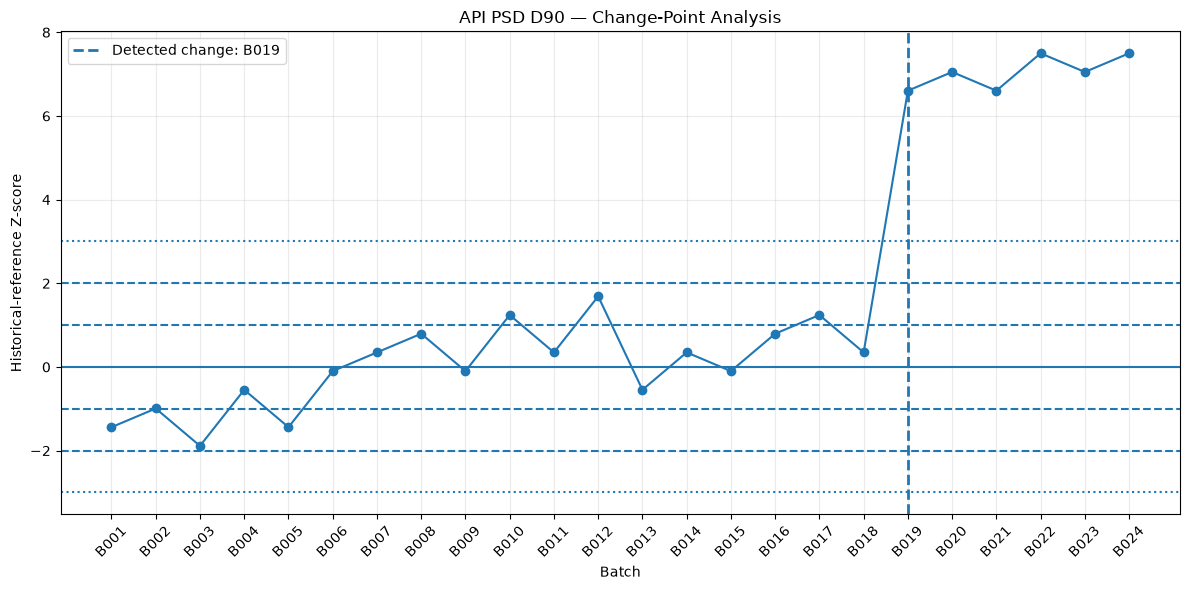

In [74]:
import matplotlib.pyplot as plt
import numpy as np

var = 'API_PSD_D90_um'
z_col = var + '_Z'

plot_data = spc_df[['Batch_ID', z_col]].dropna().reset_index(drop=True)

change_batch = change_strength_df.loc[
    change_strength_df['Variable'] == var,
    'Change_Batch'
].iloc[0]

change_index = plot_data.index[
    plot_data['Batch_ID'] == change_batch
][0]

x = np.arange(len(plot_data))

plt.figure(figsize=(12, 6))

plt.plot(
    x,
    plot_data[z_col],
    marker='o'
)

# Centerline and sigma zones
plt.axhline(0, linestyle='-')
plt.axhline(1, linestyle='--')
plt.axhline(-1, linestyle='--')
plt.axhline(2, linestyle='--')
plt.axhline(-2, linestyle='--')
plt.axhline(3, linestyle=':')
plt.axhline(-3, linestyle=':')

# Detected change point
plt.axvline(
    change_index,
    linestyle='--',
    linewidth=2,
    label=f'Detected change: {change_batch}'
)

plt.xticks(
    x,
    plot_data['Batch_ID'],
    rotation=45
)

plt.xlabel('Batch')
plt.ylabel('Historical-reference Z-score')
plt.title('API PSD D90 — Change-Point Analysis')
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

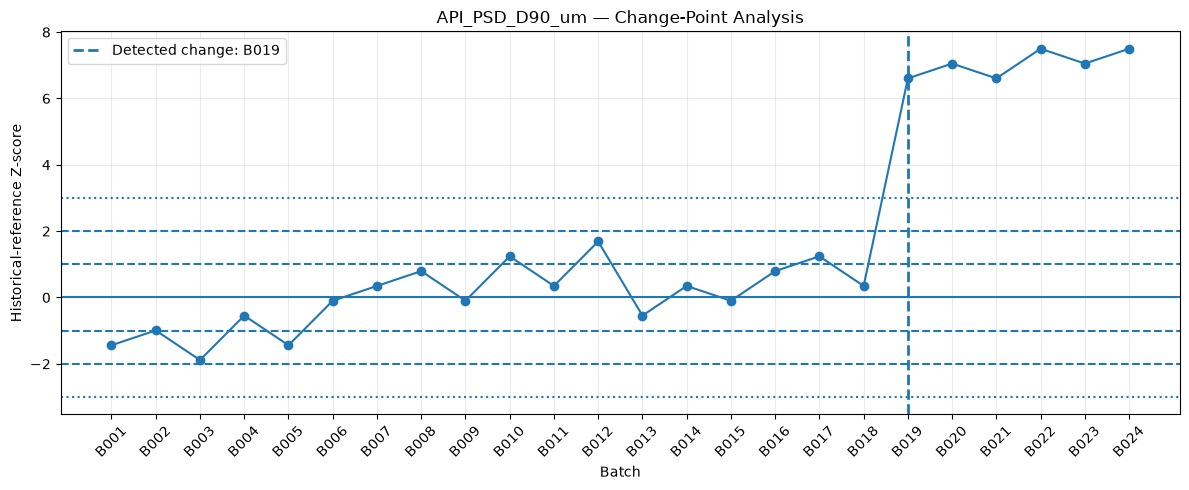

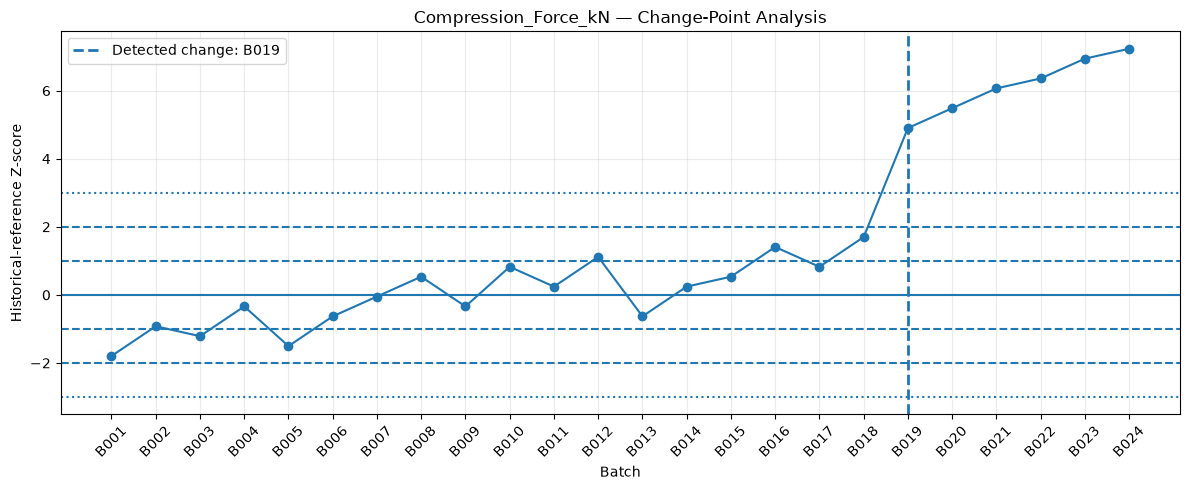

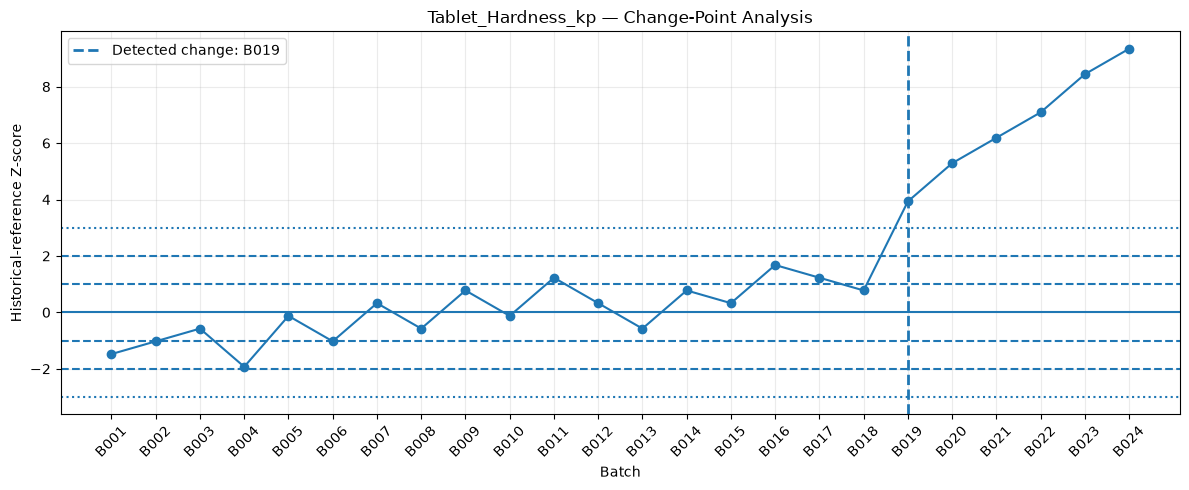

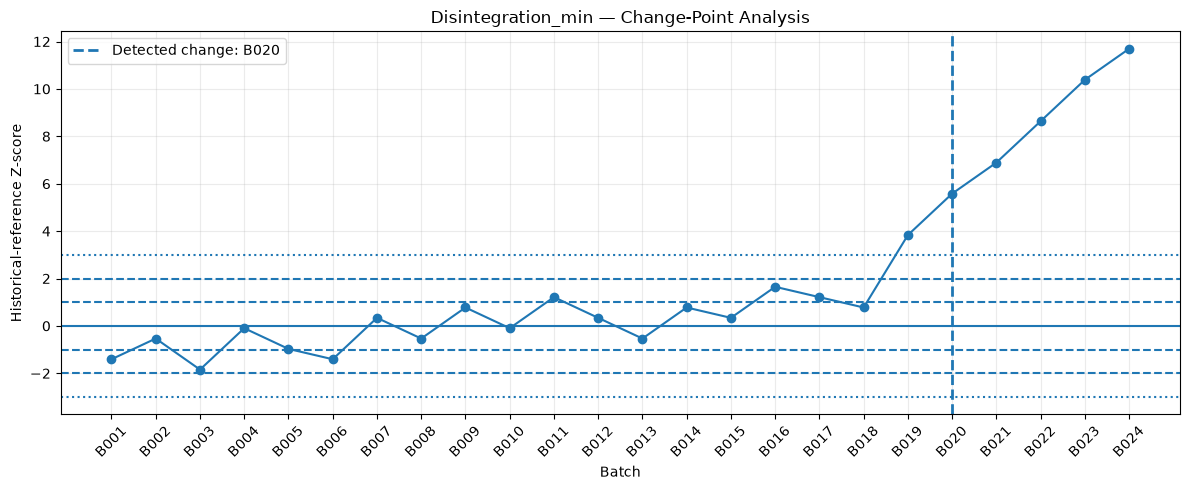

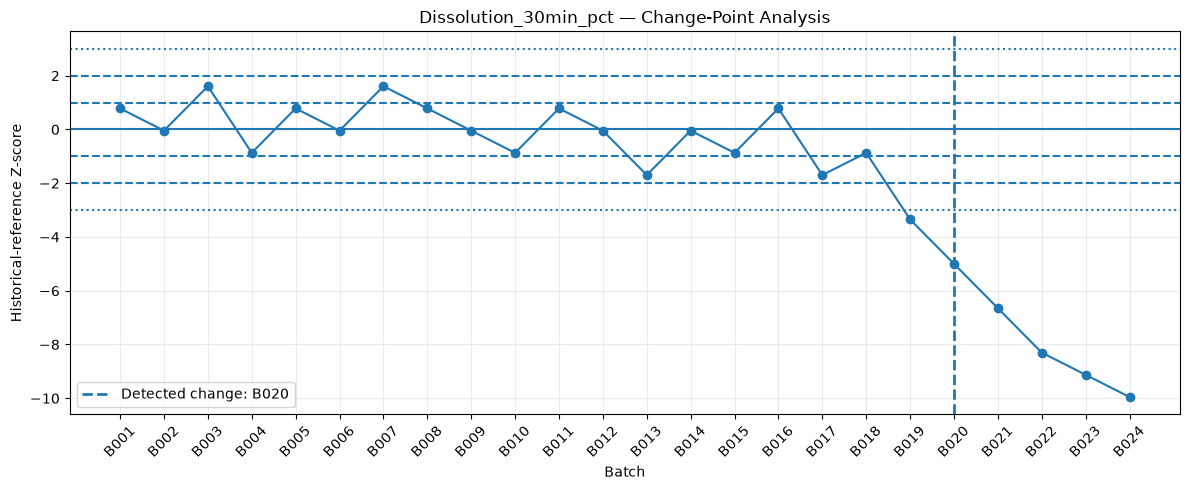

In [75]:
# Plot all variables classified as meaningful changes

for var in meaningful_changes['Variable']:

    z_col = var + '_Z'

    plot_data = spc_df[
        ['Batch_ID', z_col]
    ].dropna().reset_index(drop=True)

    change_batch = meaningful_changes.loc[
        meaningful_changes['Variable'] == var,
        'Change_Batch'
    ].iloc[0]

    change_index = plot_data.index[
        plot_data['Batch_ID'] == change_batch
    ][0]

    x = np.arange(len(plot_data))

    plt.figure(figsize=(12, 5))

    plt.plot(
        x,
        plot_data[z_col],
        marker='o'
    )

    # Centerline and sigma reference lines
    plt.axhline(0)
    plt.axhline(1, linestyle='--')
    plt.axhline(-1, linestyle='--')
    plt.axhline(2, linestyle='--')
    plt.axhline(-2, linestyle='--')
    plt.axhline(3, linestyle=':')
    plt.axhline(-3, linestyle=':')

    # Change point
    plt.axvline(
        change_index,
        linestyle='--',
        linewidth=2,
        label=f'Detected change: {change_batch}'
    )

    plt.xticks(
        x,
        plot_data['Batch_ID'],
        rotation=45
    )

    plt.xlabel('Batch')
    plt.ylabel('Historical-reference Z-score')
    plt.title(f'{var} — Change-Point Analysis')

    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 15. V2 Final Statistical Summary

Consolidate SPC run-rule signals and change-point results into an interpretable CPV summary.

In [76]:
# Build final variable-level V2 summary

summary_records = []

monitoring_data = spc_df[
    spc_df['Reference_Period'] == 'Monitoring'
]

for var in cpv_vars:

    # Which Nelson rules triggered at least once?
    triggered_rules = []

    for rule in range(1, 9):
        rule_col = f'{var}_Rule{rule}'

        if monitoring_data[rule_col].any():
            triggered_rules.append(f'R{rule}')

    # First batch with any SPC signal
    variable_rule_cols = [
        f'{var}_Rule{rule}'
        for rule in range(1, 9)
    ]

    any_signal = monitoring_data[variable_rule_cols].any(axis=1)

    if any_signal.any():
        first_alert_batch = monitoring_data.loc[
            any_signal,
            'Batch_ID'
        ].iloc[0]
    else:
        first_alert_batch = None

    # Change-point result
    change_row = change_strength_df[
        change_strength_df['Variable'] == var
    ].iloc[0]

    summary_records.append({
        'Variable': var,
        'First_SPC_Alert': first_alert_batch,
        'Rules_Triggered': ', '.join(triggered_rules) if triggered_rules else 'None',
        'Change_Batch': change_row['Change_Batch'],
        'Mean_Shift_Z': change_row['Mean_Shift_Z'],
        'SSE_Reduction_pct': change_row['SSE_Reduction_pct'],
        'Meaningful_Change': change_row['Meaningful_Change']
    })

v2_summary = pd.DataFrame(summary_records)

v2_summary

,Variable,First_SPC_Alert,Rules_Triggered,Change_Batch,Mean_Shift_Z,SSE_Reduction_pct,Meaningful_Change
0,API_PSD_D90_um,B019,"R1, R5, R6",B019,7.05,92.6,True
1,Compression_Force_kN,B019,"R1, R3, R5, R6",B019,6.16,89.1,True
2,Tablet_Hardness_kp,B019,"R1, R3, R5, R6",B019,6.71,84.5,True
3,Thickness_mm,NaN,None,B010,0.53,7.3,False
4,Tablet_Weight_mg,NaN,None,B012,0.44,6.0,False
5,Disintegration_min,B019,"R1, R3, R5, R6",B020,8.44,83.5,True
6,Dissolution_30min_pct,B019,"R1, R3, R5, R6",B020,-7.63,84.1,True


## 16. CPV Dashboard V2 — Final Dashboard

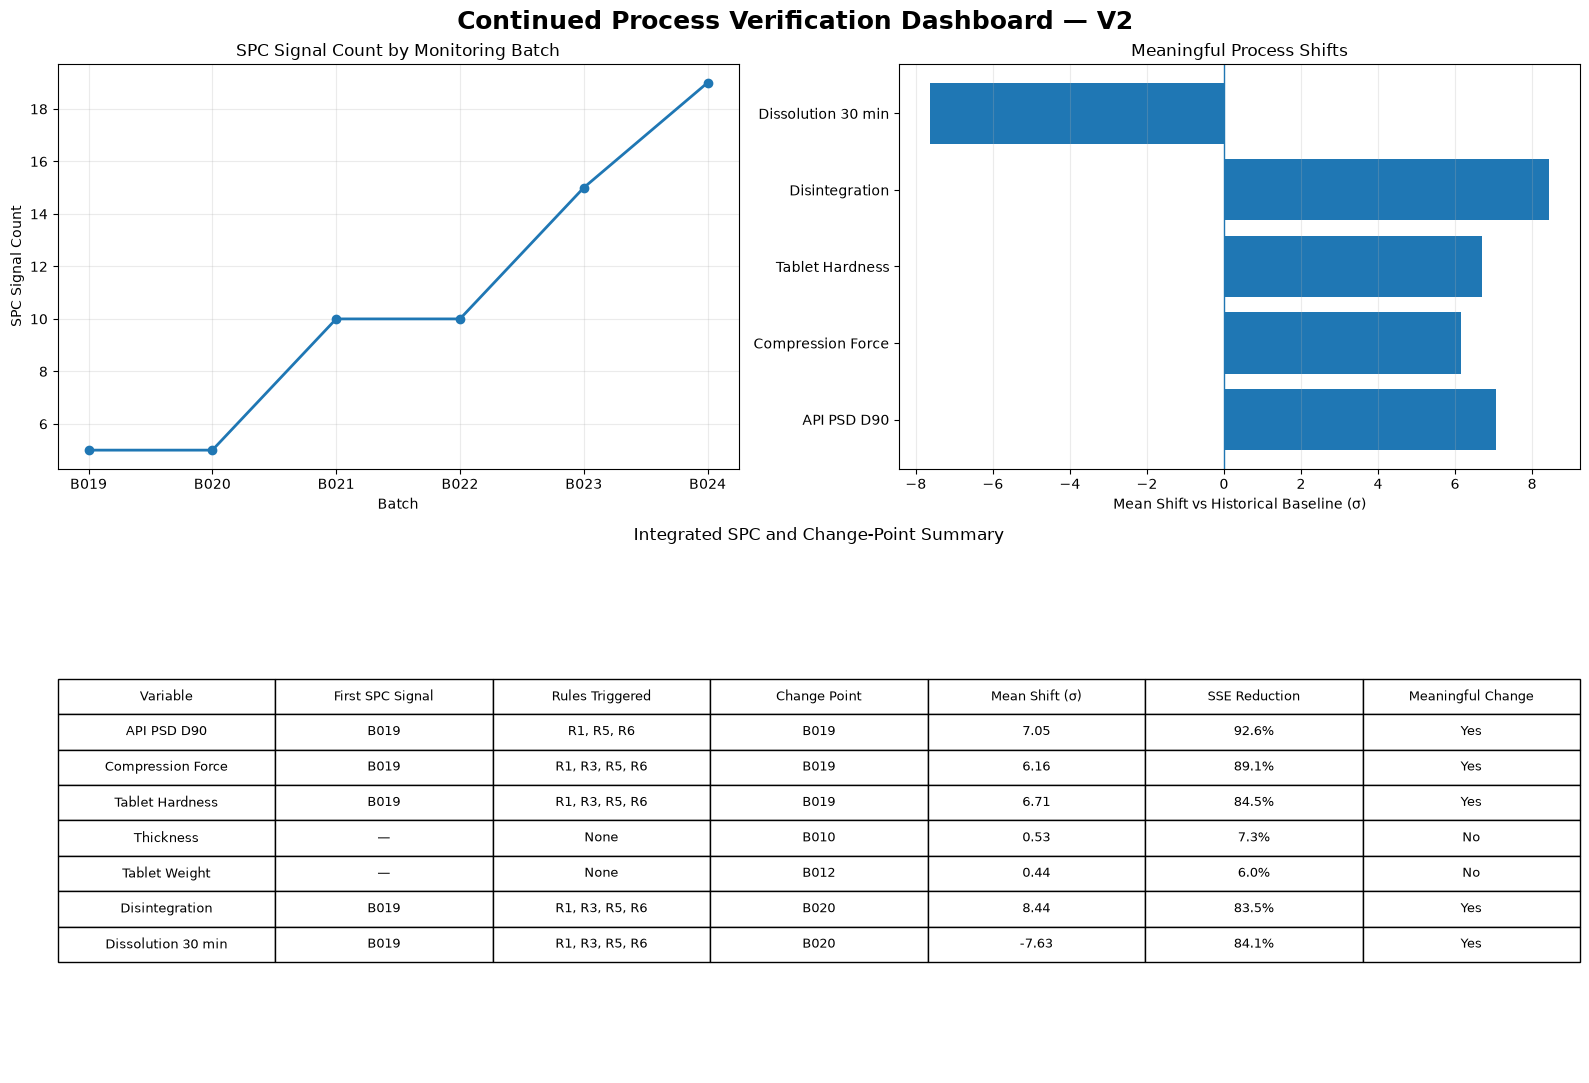

In [77]:
# Final CPV Dashboard V2

import matplotlib.pyplot as plt
import numpy as np

# Cleaner display names
display_names = {
    'API_PSD_D90_um': 'API PSD D90',
    'Compression_Force_kN': 'Compression Force',
    'Tablet_Hardness_kp': 'Tablet Hardness',
    'Thickness_mm': 'Thickness',
    'Tablet_Weight_mg': 'Tablet Weight',
    'Disintegration_min': 'Disintegration',
    'Dissolution_30min_pct': 'Dissolution 30 min'
}

monitoring_view = spc_df[
    spc_df['Reference_Period'] == 'Monitoring'
].copy()

meaningful_view = v2_summary[
    v2_summary['Meaningful_Change'] == True
].copy()

meaningful_view['Display_Name'] = meaningful_view['Variable'].map(display_names)

# Create dashboard
fig = plt.figure(figsize=(16, 11))

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1.25]
)

# ---------------------------------------------------------
# PANEL 1 — SPC alert count by monitoring batch
# ---------------------------------------------------------

ax1 = fig.add_subplot(gs[0, 0])

ax1.plot(
    monitoring_view['Batch_ID'],
    monitoring_view['SPC_Alert_Count'],
    marker='o',
    linewidth=2
)

ax1.set_title('SPC Signal Count by Monitoring Batch')
ax1.set_xlabel('Batch')
ax1.set_ylabel('SPC Signal Count')
ax1.grid(alpha=0.25)


# ---------------------------------------------------------
# PANEL 2 — Magnitude of meaningful mean shifts
# ---------------------------------------------------------

ax2 = fig.add_subplot(gs[0, 1])

ax2.barh(
    meaningful_view['Display_Name'],
    meaningful_view['Mean_Shift_Z']
)

ax2.axvline(0, linewidth=1)

ax2.set_title('Meaningful Process Shifts')
ax2.set_xlabel('Mean Shift vs Historical Baseline (σ)')
ax2.grid(axis='x', alpha=0.25)


# ---------------------------------------------------------
# PANEL 3 — V2 statistical summary table
# ---------------------------------------------------------

ax3 = fig.add_subplot(gs[1, :])
ax3.axis('off')

table_data = []

for _, row in v2_summary.iterrows():

    first_signal = row['First_SPC_Alert']

    if pd.isna(first_signal):
        first_signal = '—'

    table_data.append([
        display_names.get(row['Variable'], row['Variable']),
        first_signal,
        row['Rules_Triggered'],
        row['Change_Batch'],
        f"{row['Mean_Shift_Z']:.2f}",
        f"{row['SSE_Reduction_pct']:.1f}%",
        'Yes' if row['Meaningful_Change'] else 'No'
    ])

column_labels = [
    'Variable',
    'First SPC Signal',
    'Rules Triggered',
    'Change Point',
    'Mean Shift (σ)',
    'SSE Reduction',
    'Meaningful Change'
]

table = ax3.table(
    cellText=table_data,
    colLabels=column_labels,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)

ax3.set_title(
    'Integrated SPC and Change-Point Summary',
    pad=20
)

# ---------------------------------------------------------
# Overall dashboard title
# ---------------------------------------------------------

fig.suptitle(
    'Continued Process Verification Dashboard — V2',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
fig.savefig(
    "../dashboards/CPV_Dashboard_V2.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [78]:
fig.savefig(
    "../dashboards/CPV_Dashboard_V2.png",
    dpi=300,
    bbox_inches="tight"
)

print("V2 dashboard saved successfully")

V2 dashboard saved successfully


In [79]:
v2_summary.to_csv(
    "../outputs/CPV_Dashboard_V2_Summary.csv",
    index=False
)

change_strength_df.to_csv(
    "../outputs/CPV_Dashboard_V2_Change_Points.csv",
    index=False
)

print("V2 summary files saved successfully")

V2 summary files saved successfully


In [80]:
import os
print(os.listdir("../outputs"))

['CPV_Dashboard_V2_Change_Points.csv', 'CPV_Dashboard_V2_SPC_Alerts.csv', 'CPV_Dashboard_V2_Summary.csv']


In [81]:
rule_names = {
    1: "R1: Beyond ±3σ",
    2: "R2: 9 on same side",
    3: "R3: 6-point trend",
    4: "R4: 14 alternating",
    5: "R5: 2 of 3 beyond ±2σ",
    6: "R6: 4 of 5 beyond ±1σ",
    7: "R7: 15 within ±1σ",
    8: "R8: 8 outside ±1σ"
}

alert_records = []

monitoring_data = spc_df[
    spc_df['Reference_Period'] == 'Monitoring'
]

for _, row in monitoring_data.iterrows():
    for var in cpv_vars:

        triggered = []

        for rule in range(1, 9):
            if row[f'{var}_Rule{rule}']:
                triggered.append(rule_names[rule])

        if triggered:
            alert_records.append({
                'Batch_ID': row['Batch_ID'],
                'Variable': var,
                'Z_Score': round(row[f'{var}_Z'], 2),
                'Triggered_Rules': ' | '.join(triggered),
                'Rule_Count': len(triggered)
            })

alert_detail = pd.DataFrame(alert_records)

alert_detail.to_csv(
    "../outputs/CPV_Dashboard_V2_SPC_Alerts.csv",
    index=False
)

print("Detailed SPC alerts saved successfully")

Detailed SPC alerts saved successfully


In [82]:
import os
print(os.listdir("../dashboards"))

['CPV_Dashboard_V1.png', 'CPV_Dashboard_V2.png']


In [83]:
import os
print(os.listdir("../outputs"))

['CPV_Dashboard_V2_Change_Points.csv', 'CPV_Dashboard_V2_SPC_Alerts.csv', 'CPV_Dashboard_V2_Summary.csv']


In [84]:
# Export final V2 dashboard
fig.savefig(
     "../dashboards/CPV_Dashboard_V2.png",
    dpi=300,
    bbox_inches="tight"
)

In [85]:
import os

print(os.listdir("../dashboards"))

['CPV_Dashboard_V1.png', 'CPV_Dashboard_V2.png']


# V3 — Predictive Modeling, XGBoost, SHAP, and Applicability Domain

This section extends the V2 CPV workflow from **detection/diagnosis** into **prediction and explainability**.

### Design principles
- 720 synthetic batches across 18 API lots.
- Lot-aware splits: 10 training lots, 3 validation lots, 3 unseen test lots, and 2 out-of-domain stress lots.
- API lot identity is **not** used as a model feature.
- `Disintegration_min` remains available for CPV context but is intentionally excluded from the early-warning feature set to reduce target leakage.
- Hyperparameter tuning uses **GroupKFold by API lot**, not random row CV.
- Performance is reported separately for validation, unseen test lots, and an intentionally out-of-domain stress set.
- SHAP is used for global and batch-level explanation.
- A nearest-neighbor applicability-domain check flags predictions outside the training envelope.

> This remains a synthetic proof-of-concept. It demonstrates a defensible modeling workflow, not a validated GMP production model.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

import xgboost as xgb
import shap

predictive_df = pd.read_csv("CPV_Predictive_Modeling_Synthetic_720.csv")
print("Shape:", predictive_df.shape)
print(predictive_df.groupby("Dataset_Split").agg(
    rows=("Batch_ID", "size"),
    api_lots=("API_Lot", "nunique")
))

## Feature strategy

The target is **dissolution at 30 minutes**. The early-warning feature set uses material, process, and in-process tablet attributes available before the dissolution result.

`API_Lot` is used only for grouped validation and is not provided to the model. `Disintegration_min` is deliberately excluded from the predictive features because it is a downstream performance result and could make the early-warning use case artificially easy.

In [ ]:
features = [
    "API_PSD_D90_um",
    "Bulk_Density_g_mL",
    "Blend_Moisture_pct",
    "Lubrication_Time_min",
    "Press_Speed_rpm",
    "Feeder_Speed_rpm",
    "Compression_Force_kN",
    "Tablet_Weight_mg",
    "Tablet_Hardness_kp",
    "Thickness_mm",
]
target = "Dissolution_30min_pct"

train = predictive_df[predictive_df["Dataset_Split"] == "Train"].copy()
validation = predictive_df[predictive_df["Dataset_Split"] == "Validation"].copy()
test = predictive_df[predictive_df["Dataset_Split"] == "Test"].copy()
stress = predictive_df[predictive_df["Dataset_Split"] == "Stress"].copy()

print("Train:", train.shape, "Validation:", validation.shape,
      "Test:", test.shape, "Stress:", stress.shape)

## Baselines before XGBoost
A complex model should beat simpler baselines on unseen lots, not just fit the training data.

In [ ]:
linear = LinearRegression().fit(train[features], train[target])

rf = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=3,
    max_features=0.8,
    random_state=42,
    n_jobs=-1,
).fit(train[features], train[target])

## Group-aware XGBoost tuning
Cross-validation folds are separated by API lot to reduce leakage from lot-specific patterns.

In [ ]:
param_dist = {
    "n_estimators": [200, 350, 500, 700],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.02, 0.035, 0.05, 0.07],
    "min_child_weight": [3, 5, 8, 12],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_lambda": [1, 3, 6, 10],
    "reg_alpha": [0, 0.05, 0.2, 0.5],
    "gamma": [0, 0.05, 0.15],
}

search = RandomizedSearchCV(
    xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    ),
    param_distributions=param_dist,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=GroupKFold(n_splits=5),
    random_state=42,
    n_jobs=-1,
)

search.fit(
    train[features],
    train[target],
    groups=train["API_Lot"],
)

xgb_model = search.best_estimator_
print("Best grouped-CV RMSE:", round(-search.best_score_, 3))
print("Best parameters:")
print(search.best_params_)

## Generalization results

In [ ]:
def metrics(name, split_name, df_part, model):
    pred = model.predict(df_part[features])
    return {
        "Model": name,
        "Split": split_name,
        "N": len(df_part),
        "MAE": mean_absolute_error(df_part[target], pred),
        "RMSE": mean_squared_error(df_part[target], pred) ** 0.5,
        "R2": r2_score(df_part[target], pred),
    }

rows = []
for model_name, model in [
    ("Linear Regression", linear),
    ("Random Forest", rf),
    ("Tuned XGBoost", xgb_model),
]:
    for split_name, part in [
        ("Validation — unseen lots", validation),
        ("Test — unseen lots", test),
        ("Stress — outside envelope", stress),
    ]:
        rows.append(metrics(model_name, split_name, part, model))

performance = pd.DataFrame(rows)
performance.round(3)

### Interpretation

The **unseen-lot test set** is the main generalization result. The **stress set is intentionally outside the development envelope** and should not be treated as another ordinary test set.

A good model-governance result is not “the model predicts everything.” It is:  
**the model performs acceptably in-domain, and the workflow detects when the process moves outside the domain where predictions are supportable.**

In [ ]:
test_pred = xgb_model.predict(test[features])

plt.figure(figsize=(8, 5))
plt.scatter(test[target], test_pred)
mn = min(test[target].min(), test_pred.min())
mx = max(test[target].max(), test_pred.max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Actual dissolution @30 min (%)")
plt.ylabel("Predicted dissolution @30 min (%)")
plt.title("Tuned XGBoost — Unseen API Lots")
plt.tight_layout()
plt.show()

## SHAP — global explanation on unseen lots

In [ ]:
explainer = shap.TreeExplainer(xgb_model)
test_shap = explainer.shap_values(test[features])

shap_importance = pd.DataFrame({
    "Feature": features,
    "Mean_Absolute_SHAP": np.abs(test_shap).mean(axis=0),
}).sort_values("Mean_Absolute_SHAP", ascending=False)

shap_importance

In [ ]:
plot_df = shap_importance.sort_values("Mean_Absolute_SHAP", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["Feature"], plot_df["Mean_Absolute_SHAP"])
plt.xlabel("Mean absolute SHAP contribution (percentage points)")
plt.ylabel("Feature")
plt.title("XGBoost Explainability — Unseen API Lots")
plt.tight_layout()
plt.show()

## SHAP — batch-level explanation

In [ ]:
errors = np.abs(test[target].to_numpy() - test_pred)
worst_idx = int(np.argmax(errors))
worst_batch = test.iloc[worst_idx]

local = pd.DataFrame({
    "Feature": features,
    "Feature_Value": worst_batch[features].to_numpy(),
    "SHAP_Contribution_pp": test_shap[worst_idx],
})
local["Abs_SHAP"] = local["SHAP_Contribution_pp"].abs()

print("Batch:", worst_batch["Batch_ID"])
print("API lot:", worst_batch["API_Lot"])
print("Actual dissolution:", worst_batch[target])
print("Predicted dissolution:", round(float(test_pred[worst_idx]), 2))
local.sort_values("Abs_SHAP", ascending=False).head(8)

## Applicability domain / out-of-domain detection

In [ ]:
scaler = StandardScaler().fit(train[features])
X_train_scaled = scaler.transform(train[features])

train_nn = NearestNeighbors(n_neighbors=2).fit(X_train_scaled)
train_dists, _ = train_nn.kneighbors(X_train_scaled)
ood_threshold = np.quantile(train_dists[:, 1], 0.95)

reference_nn = NearestNeighbors(n_neighbors=1).fit(X_train_scaled)

def ood_rate(df_part):
    X = scaler.transform(df_part[features])
    d, _ = reference_nn.kneighbors(X)
    return (d[:, 0] > ood_threshold).mean(), d[:, 0]

test_ood_rate, test_dist = ood_rate(test)
stress_ood_rate, stress_dist = ood_rate(stress)

print("95th-percentile training-envelope threshold:", round(float(ood_threshold), 3))
print("Unseen test lots flagged OOD:", f"{test_ood_rate:.1%}")
print("Stress lots flagged OOD:", f"{stress_ood_rate:.1%}")

## Model-use statement

This proof-of-concept supports the following claim:

> A lot-aware XGBoost workflow can learn nonlinear relationships between material/process attributes and dissolution performance, explain batch-level predictions with SHAP, and flag observations that fall outside the model-development envelope.

It does **not** support a claim that the model is validated for GMP decision-making. Before operational use, the same workflow would require representative historical data, predefined model acceptance criteria, controlled data lineage, prospective verification, change control, and lifecycle monitoring.